# VoltRelay Energy | Data Analytics Hackathon

**Evidence rule:** every reported quantity and finding below is computed from the loaded CSVs. No results are pre-filled. If inputs are missing, keys do not join, or samples are too small, the notebook raises an error or marks the result unavailable. This is observational analysis; associations are not causal effects.

The swap log is streamed in chunks. Summary outputs and cleaned event data are saved under `outputs/` so later sections do not reread the raw event file. Run top to bottom in Colab or locally. The last cell writes the report, video script, LinkedIn drafts and checklist from calculated outputs; it never fills unsupported findings with generic claims.

## 00. Get the eight datasets into Google Colab

**Upload to the current Colab session:** open the Files panel and upload all eight CSV files into the notebook working folder (normally `/content`). Keep these exact filenames: `swap_events.csv`, `station_hourly_status.csv`, `riders.csv`, `batteries.csv`, `support_tickets.csv`, `stations.csv`, `city_daily_context.csv`, and `fleet_partners.csv`. The default `DATA_DIR = Path(".")` below reads them from the current folder. Session uploads are temporary.

**Use Google Drive instead:** run `from google.colab import drive; drive.mount('/content/drive')`, put the eight files in one Drive folder, then change `DATA_DIR` below to that folder, for example `Path('/content/drive/MyDrive/VoltRelay')`. Keep all eight files together. Then use **Runtime → Run all**.

## 01. Executive Summary

Generated in the final cell after all calculations complete; no executive claims are written in advance.

## 02. Business Problem

Assess network growth, service quality, station and equipment differences, unit economics, and rider repeat behavior for VoltRelay. The observational data can describe patterns and associations, not prove that operational or pricing changes caused outcomes.

## 03. Dataset Overview

Eight expected CSV files: swap events, station-hour telemetry, riders, batteries, tickets, stations, city-day context, and fleet partners. File existence, row counts, schemas, and key cardinalities are checked below.

## 04. Data Loading

In [3]:
from pathlib import Path
import json, math, warnings, tempfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

DATA_DIR = Path(".")  # The eight CSVs are beside the notebook; change this for another folder.
# Backward-compatible fallback for copies that keep the CSVs in a data/ subfolder.
if not (DATA_DIR / 'swap_events.csv').is_file() and (Path('data') / 'swap_events.csv').is_file():
    DATA_DIR = Path('data')
OUT = DATA_DIR / 'outputs'
OUT.mkdir(parents=True, exist_ok=True)
FILES = ['swap_events.csv','station_hourly_status.csv','riders.csv','batteries.csv',
         'support_tickets.csv','stations.csv','city_daily_context.csv','fleet_partners.csv']
missing = [f for f in FILES if not (DATA_DIR/f).is_file()]
if missing:
    raise FileNotFoundError(f'Required input CSV(s) missing under {DATA_DIR.resolve()}: ' + ', '.join(missing) + '. Put all eight CSVs beside the notebook or set DATA_DIR to their folder.')
CHUNK = 200_000
small = {f: pd.read_csv(DATA_DIR/f) for f in FILES if f != 'swap_events.csv' and f != 'station_hourly_status.csv'}
stations, riders, batteries = small['stations.csv'], small['riders.csv'], small['batteries.csv']
partners, tickets, city_context = small['fleet_partners.csv'], small['support_tickets.csv'], small['city_daily_context.csv']
required = {
 'swap_events.csv': {'event_id','rider_id','station_id','event_ts','event_type','queue_wait_sec','battery_in_id','battery_out_id','tariff_code','amount_charged_inr','energy_to_recharge_kwh','station_firmware','sync_mode'},
 'stations.csv': {'station_id','city','firmware_version','connectivity_tier','slots_2w','slots_3w','monthly_rent_inr','monthly_maintenance_inr','grid_tariff_inr_kwh'},
 'riders.csv': {'rider_id','partner_id','vehicle_class','signup_date','plan_type','home_city'},
 'batteries.csv': {'battery_id','supplier','pack_type','manufacture_date','commission_date','current_soh_pct'},
 'station_hourly_status.csv': {'station_id','hour_start','telemetry_status','charged_2w_min','charged_3w_min','outage_minutes'},
 'support_tickets.csv': {'ticket_id','rider_id','created_ts','category','csat_score'},
 'city_daily_context.csv': {'city','date'}, 'fleet_partners.csv': {'partner_id','discount_pct','contract_type'} }
for f, cols in required.items():
    head = pd.read_csv(DATA_DIR/f, nrows=0)
    absent = cols - set(head.columns)
    if absent: raise ValueError(f'{f}: required columns absent: {sorted(absent)}')
for df, key, name in [(stations,'station_id','stations'),(riders,'rider_id','riders'),(batteries,'battery_id','batteries'),(partners,'partner_id','partners'),(tickets,'ticket_id','tickets'),(city_context,['city','date'],'city_context')]:
    if df.duplicated(key).any(): warnings.warn(f'{name} has duplicate key rows; validate before joining')
counts = {f: sum(1 for _ in open(DATA_DIR/f, encoding='utf-8'))-1 for f in FILES}
display(pd.DataFrame({'file':counts.keys(),'rows':counts.values(),'bytes':[ (DATA_DIR/f).stat().st_size for f in counts]}))
print('Small-table key checks complete. Event rows will be streamed in',CHUNK,'row chunks.')

,file,rows,bytes
0,swap_events.csv,3877013,728731022
1,station_hourly_status.csv,1487712,108351982
2,riders.csv,20000,2098502
3,batteries.csv,6500,624010
4,support_tickets.csv,44000,6537443
5,stations.csv,152,23517
6,city_daily_context.csv,3282,223397
7,fleet_partners.csv,12,1179


Small-table key checks complete. Event rows will be streamed in 200000 row chunks.


## 05. Data Quality Audit & 06. Cleaning

In [4]:
# Explicit city standardization; unmapped spellings remain visible in the audit.
city_map = {'Bangalore':'Bengaluru','Bengaluru':'Bengaluru','Bengaluru Urban':'Bengaluru','BLR':'Bengaluru',
 'Delhi':'Delhi NCR','Delhi NCR':'Delhi NCR','New Delhi':'Delhi NCR','Gurgaon':'Delhi NCR','Gurugram':'Delhi NCR','Noida':'Delhi NCR',
 'HYD':'Hyderabad','Hyd':'Hyderabad','Hyderabad':'Hyderabad','PUN':'Pune','Pune':'Pune','MUM':'Mumbai','Mumbai':'Mumbai','Bombay':'Mumbai','JAI':'Jaipur','Jaipur':'Jaipur'}
city_map_fold = {k.casefold().strip():v for k,v in city_map.items()}
for df in [riders, stations, city_context]:
    if 'city' in df: df['city_raw'] = df['city']; df['city'] = df['city'].astype('string').str.strip().map(lambda x: city_map_fold.get(x.casefold(), x) if pd.notna(x) else x)
if 'home_city' in riders:
    riders['home_city_raw'] = riders['home_city']
    riders['home_city'] = riders['home_city'].astype('string').str.strip().map(lambda x: city_map_fold.get(x.casefold(), x) if pd.notna(x) else x)
city_audit = riders[['home_city_raw','home_city']].drop_duplicates().sort_values('home_city_raw')
display(city_audit)
unmapped = sorted(x for x in riders.home_city_raw.dropna().unique() if str(x).strip().casefold() not in city_map_fold)
print('Unmapped rider city labels:', unmapped)
stations['is_test_station'] = stations.station_id.astype(str).str.startswith('STN-TST')
print('Test stations excluded from network KPIs:', int(stations.is_test_station.sum()), 'of', len(stations))

# Known firmware timestamp issue: correction is limited to the specified firmware and date window.
# The nominal 5h30 shift is applied only to qualifying event rows; affected count is printed after streaming.
stations_dim = stations.set_index('station_id', drop=False)


,home_city_raw,home_city
404,BLR,Bengaluru
51,Bangalore,Bengaluru
13,Bengaluru,Bengaluru
114,Bombay,Mumbai
3067,Delhi,Delhi NCR
0,Delhi NCR,Delhi NCR
572,Gurgaon,Delhi NCR
224,HYD,Hyderabad
520,Hyd,Hyderabad
2,Hyderabad,Hyderabad


Unmapped rider city labels: []
Test stations excluded from network KPIs: 2 of 152


## 07. KPI Definitions

Attempts are event rows; completed swaps are `event_type == swap_completed`. Failure rate is failed attempts divided by all attempts. Abandoned share is separately reported when that event label exists. Revenue proxy is sum of `amount_charged_inr` across completed swaps. Estimated energy cost is `energy_to_recharge_kwh × station grid tariff`. Contribution proxy is charged revenue minus estimated energy cost; it excludes rent allocation, maintenance allocation, labor, payment fees, battery depreciation and other accounting costs, so it is not official contribution margin. Per-swap proxy uses completed swaps as the denominator. Missing values are not turned into zero unless a metric definition requires summing observed transaction amounts.

## 08. Network Performance Over Time

In [5]:
# Stream, audit and create an analysis table. Deliberate duplicate review: only offline_batch
# records matching same rider/station/battery pair within 120 seconds and same event type
# are flagged. We retain all rows in primary KPIs; flagged count is a sensitivity diagnostic.
event_dir=DATA_DIR/'.voltrelay_scratch'
event_dir.mkdir(exist_ok=True)
event_path=event_dir/'events_clean.csv'
if event_path.exists(): event_path.unlink()
event_writer=event_path.open('w',encoding='utf-8',newline='')
monthly_parts=[]; city_parts=[]; hour_parts=[]; station_parts=[]; tariff_parts=[]; rider_parts=[]; battery_parts=[]; station_hour_parts=[]
audit = {'rows_read':0,'bad_timestamp':0,'negative_distance':0,'large_distance_gt_300km':0,
         'soc_over_100':0,'soh_over_100':0,'offline_duplicate_candidates':0,'unmatched_station':0}
first=True
for raw in pd.read_csv(DATA_DIR/'swap_events.csv', chunksize=CHUNK, low_memory=False):
    audit['rows_read'] += len(raw)
    raw['event_ts'] = pd.to_datetime(raw.event_ts, errors='coerce')
    bad = raw.event_ts.isna(); audit['bad_timestamp'] += int(bad.sum())
    fw32 = raw.station_firmware.eq('v3.2.0')
    # Events appear early by 5h30, so the raw timestamp interval is shifted back accordingly.
    affected = fw32 & raw.event_ts.ge('2025-03-09 18:30:00') & raw.event_ts.lt('2025-04-14 18:30:00')
    raw.loc[affected,'event_ts'] = raw.loc[affected,'event_ts'] + pd.Timedelta(hours=5, minutes=30)
    audit['firmware_timestamp_corrected'] = audit.get('firmware_timestamp_corrected',0)+int(affected.sum())
    audit['negative_distance'] += int(raw.km_since_last_swap.lt(0).sum())
    audit['large_distance_gt_300km'] += int(raw.km_since_last_swap.gt(300).sum())
    for c in ['soc_in_pct','soc_out_pct']:
        if c in raw: audit['soc_over_100'] += int(raw[c].gt(100).sum())
    for c in ['soh_in_pct','soh_out_pct']:
        if c in raw: audit['soh_over_100'] += int(raw[c].gt(100).sum())
    raw['is_test_station'] = raw.station_id.astype(str).str.startswith('STN-TST')
    raw = raw.loc[~raw.is_test_station].copy()
    # Candidate detection is deliberately conservative and does not remove records.
    raw['dup_key'] = raw[['rider_id','station_id','battery_in_id','battery_out_id','event_type']].fillna('').astype(str).agg('|'.join,axis=1)
    offline = raw.sync_mode.eq('offline_batch')
    near = raw.loc[offline].sort_values(['dup_key','event_ts'])
    close = near.groupby('dup_key',dropna=False).event_ts.diff().dt.total_seconds().between(0,120)
    audit['offline_duplicate_candidates'] += int(close.sum())
    raw['distance_flag'] = raw.km_since_last_swap.lt(0) | raw.km_since_last_swap.gt(300)
    raw['event_month'] = raw.event_ts.dt.to_period('M').astype(str)
    raw['event_hour'] = raw.event_ts.dt.hour
    raw['completed'] = raw.event_type.eq('swap_completed')
    raw['failed'] = raw.event_type.str.contains('fail',case=False,na=False)
    raw['abandoned'] = raw.event_type.str.contains('abandon',case=False,na=False)
    raw['station_city'] = raw.station_id.map(stations_dim.city)
    raw['grid_tariff'] = raw.station_id.map(stations_dim.grid_tariff_inr_kwh)
    raw['energy_cost_est'] = raw.energy_to_recharge_kwh * raw.grid_tariff
    # Restrict primary time-series to requested interval; all other rows remain available in event output.
    window = raw.event_ts.ge('2024-01-01') & raw.event_ts.lt('2025-07-01')
    x = raw.loc[window]
    if len(x):
        g=x.groupby('event_month').agg(attempts=('event_id','size'),completed=('completed','sum'),failures=('failed','sum'),abandoned=('abandoned','sum'),revenue_inr=('amount_charged_inr','sum'),energy_kwh=('energy_to_recharge_kwh','sum'),energy_cost_est=('energy_cost_est','sum'),queue_wait_sum=('queue_wait_sec','sum'),queue_wait_n=('queue_wait_sec','count')).reset_index()
        monthly_parts.append(g)
        sx=x.assign(station_hour=x.event_ts.dt.floor('h')).groupby(['station_id','station_hour']).agg(attempts=('event_id','size'),completed=('completed','sum'),failures=('failed','sum'),abandoned=('abandoned','sum'),queue_wait_sum=('queue_wait_sec','sum'),queue_wait_n=('queue_wait_sec','count')).reset_index()
        station_hour_parts.append(sx)
        for key, dest in [('station_city',city_parts),('event_hour',hour_parts),('station_id',station_parts),('tariff_code',tariff_parts)]:
            q=x.groupby(key).agg(attempts=('event_id','size'),completed=('completed','sum'),failures=('failed','sum'),abandoned=('abandoned','sum'),revenue_inr=('amount_charged_inr','sum'),energy_cost_est=('energy_cost_est','sum'),queue_wait_sum=('queue_wait_sec','sum'),queue_wait_n=('queue_wait_sec','count')).reset_index(); dest.append(q)
        # Per-rider event summaries permit transparent cohort/first-experience associations.
        r=x.groupby('rider_id').agg(attempts=('event_id','size'),completed=('completed','sum'),failures=('failed','sum'),first_event=('event_ts','min'),first_wait_sec=('queue_wait_sec','first'),revenue=('amount_charged_inr','sum')).reset_index(); rider_parts.append(r)
        b=x[x.completed].groupby('battery_out_id').agg(delivered_soh_sum=('soh_out_pct','sum'),swaps=('event_id','size')).reset_index(); battery_parts.append(b)
    raw.drop(columns=['dup_key','is_test_station','station_city','grid_tariff','energy_cost_est','event_month','event_hour','completed','failed','abandoned','distance_flag'],errors='ignore').to_csv(event_writer,index=False,header=first)
    first=False
event_writer.close()
monthly=pd.concat(monthly_parts,ignore_index=True).groupby('event_month',as_index=False).sum(numeric_only=True)
for d in [city_parts,hour_parts,station_parts,tariff_parts,battery_parts]:
    pass
def combine(parts,key):
    if not parts:return pd.DataFrame()
    z=pd.concat(parts,ignore_index=True); n=[c for c in z.select_dtypes('number') if c!=key]
    return z.groupby(key,as_index=False)[n].sum()
city_kpi=combine(city_parts,'station_city'); hour_kpi=combine(hour_parts,'event_hour'); station_kpi=combine(station_parts,'station_id'); tariff_kpi=combine(tariff_parts,'tariff_code')
rider_event=combine(rider_parts,'rider_id'); battery_event=combine(battery_parts,'battery_out_id')
for df in [monthly,city_kpi,hour_kpi,station_kpi,tariff_kpi]:
    if len(df):
        df['failure_rate']=df.failures/df.attempts; df['abandon_rate']=df.abandoned/df.attempts
        df['queue_wait_sec']=df.queue_wait_sum/df.queue_wait_n.replace(0,np.nan)
        df['contribution_proxy_inr']=df.revenue_inr-df.energy_cost_est; df['contribution_proxy_per_completed_swap']=df.contribution_proxy_inr/df.completed.replace(0,np.nan)
monthly['failure_rate']=monthly.failures/monthly.attempts
monthly['contribution_proxy_inr']=monthly.revenue_inr-monthly.energy_cost_est
monthly['contribution_proxy_per_completed_swap']=monthly.contribution_proxy_inr/monthly.completed.replace(0,np.nan)
battery_event['delivered_soh']=battery_event.delivered_soh_sum/battery_event.swaps.replace(0,np.nan)
display(monthly)
display(pd.Series(audit,name='count').to_frame())


,event_month,attempts,completed,failures,abandoned,revenue_inr,energy_kwh,energy_cost_est,queue_wait_sum,queue_wait_n,failure_rate,abandon_rate,queue_wait_sec,contribution_proxy_inr,contribution_proxy_per_completed_swap
0,2024-01,108278,103508,2956,1371,6198803.40,244532.249,2.277787e+06,26218627,108278,0.027300,0.012662,242.141774,3.921016e+06,37.881286
1,2024-02,109271,104437,2956,1421,6256296.00,245471.893,2.287104e+06,26612349,109271,0.027052,0.013004,243.544481,3.969192e+06,38.005611
2,2024-03,121487,116148,3256,1539,6952642.00,270671.657,2.522070e+06,29419235,121487,0.026801,0.012668,242.159531,4.430572e+06,38.145921
3,2024-04,128991,120117,5722,2643,7204036.20,278471.249,2.593933e+06,31381758,128991,0.044360,0.020490,243.286415,4.610103e+06,38.380105
4,2024-05,143189,125454,11629,5452,7513212.80,287121.396,2.676062e+06,34761056,143189,0.081214,0.038076,242.763452,4.837151e+06,38.557169
5,2024-06,145880,130880,9825,4549,7827373.00,295809.161,2.752443e+06,35341658,145880,0.067350,0.031183,242.265273,5.074930e+06,38.775440
6,2024-07,155343,148611,4101,1995,9666799.25,333932.496,3.099532e+06,37780081,155343,0.026400,0.012843,243.204271,6.567267e+06,44.190988
7,2024-08,168900,161688,4336,2130,10509533.60,359454.285,3.338423e+06,41087093,168900,0.025672,0.012611,243.262836,7.171111e+06,44.351533
8,2024-09,192479,184051,5207,2403,11903273.70,404952.905,3.765599e+06,46758129,192479,0.027052,0.012484,242.925872,8.137674e+06,44.214236
9,2024-10,226458,216551,6050,2860,14348597.95,469808.981,4.379886e+06,55052826,226458,0.026716,0.012629,243.103913,9.968712e+06,46.034013


,count
rows_read,3877013
bad_timestamp,0
negative_distance,7814
large_distance_gt_300km,7712
soc_over_100,3698
soh_over_100,6155
offline_duplicate_candidates,0
unmatched_station,0
firmware_timestamp_corrected,141280


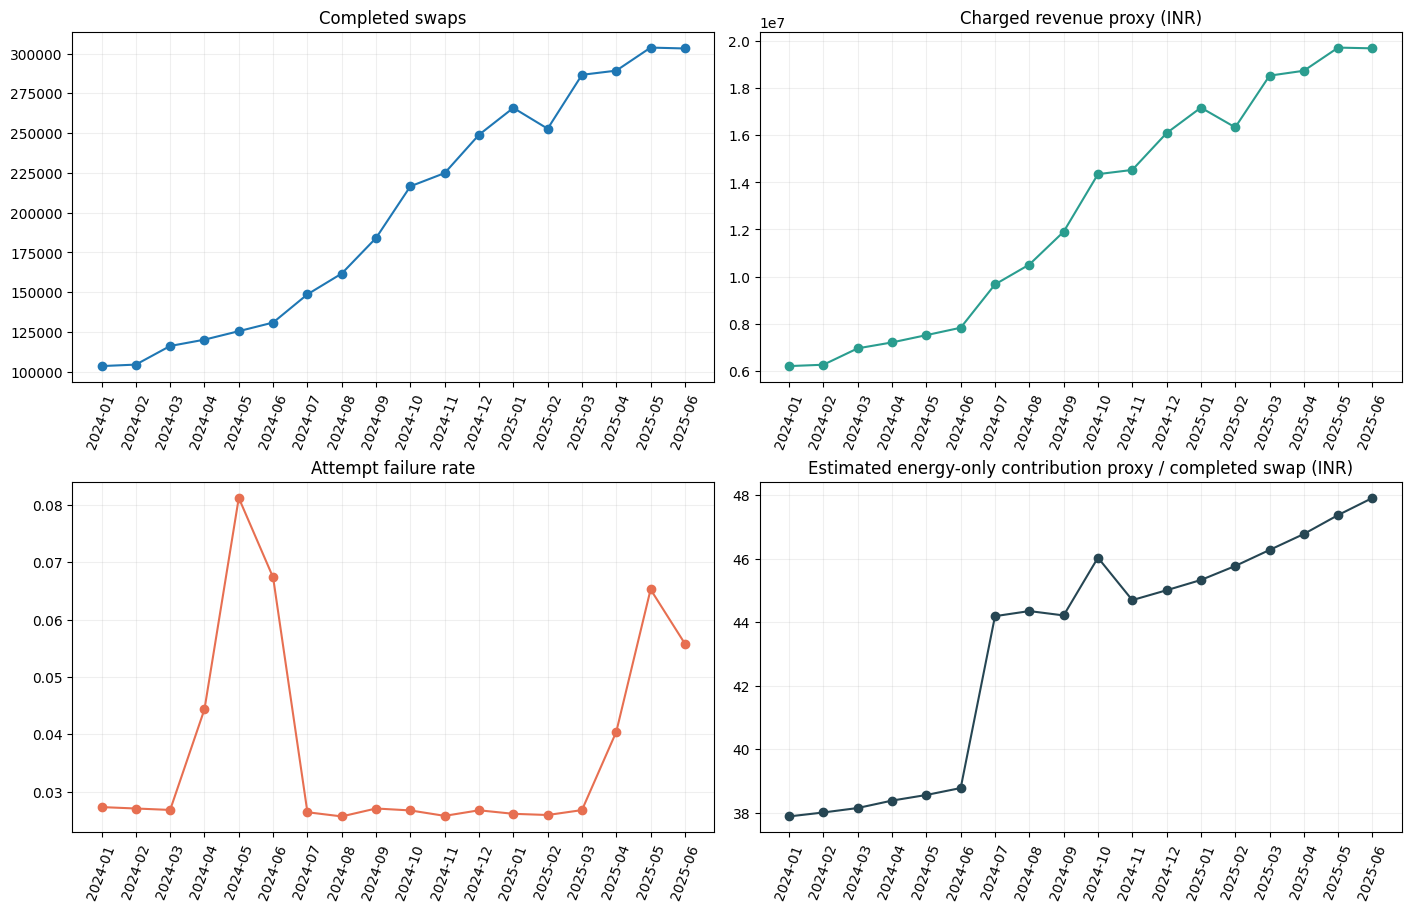

In [6]:
fig, ax = plt.subplots(2,2,figsize=(14,9),constrained_layout=True)
ax[0,0].plot(monthly.event_month,monthly.completed,marker='o'); ax[0,0].set_title('Completed swaps'); ax[0,0].tick_params(axis='x',rotation=70)
ax[0,1].plot(monthly.event_month,monthly.revenue_inr,marker='o',color='#2a9d8f'); ax[0,1].set_title('Charged revenue proxy (INR)'); ax[0,1].tick_params(axis='x',rotation=70)
ax[1,0].plot(monthly.event_month,monthly.failure_rate,marker='o',color='#e76f51'); ax[1,0].set_title('Attempt failure rate'); ax[1,0].tick_params(axis='x',rotation=70)
ax[1,1].plot(monthly.event_month,monthly.contribution_proxy_per_completed_swap,marker='o',color='#264653'); ax[1,1].set_title('Estimated energy-only contribution proxy / completed swap (INR)'); ax[1,1].tick_params(axis='x',rotation=70)
for a in ax.flat:a.grid(alpha=.2)
plt.show()


## 09. Service Failure & Customer Experience

Event-level failures, abandonments and waits are summarized by city, hour, and station. The telemetry join below uses station and floored hour, validates uniqueness, and excludes telemetry marked missing from averages; partial readings remain labeled and are shown separately. Telemetry state is never imputed as zero.

,station_city,attempts,completed,failures,abandoned,revenue_inr,energy_cost_est,queue_wait_sum,queue_wait_n,failure_rate,abandon_rate,queue_wait_sec,contribution_proxy_inr,contribution_proxy_per_completed_swap
3,Jaipur,487634,449366,24677,11518,28229052.85,8.704691e+06,118629987,487634,0.050606,0.023620,243.276693,1.952436e+07,43.448685
1,Delhi NCR,768913,712385,36197,17030,44565107.85,1.345959e+07,186632379,768913,0.047076,0.022148,242.722361,3.110552e+07,43.663912
2,Hyderabad,711930,664312,30427,14158,41521622.25,1.266184e+07,172846215,711930,0.042739,0.019887,242.785407,2.885978e+07,43.443119
5,Pune,552910,525331,17127,8081,34766281.90,9.912458e+06,134361256,552910,0.030976,0.014615,243.007462,2.485382e+07,47.310788
0,Bengaluru,763296,728563,21317,10049,48023983.20,1.411198e+07,185385066,763296,0.027928,0.013165,242.874410,3.391200e+07,46.546420
4,Mumbai,530299,506718,14441,6827,32089247.45,1.106720e+07,128992137,530299,0.027232,0.012874,243.244164,2.102205e+07,41.486682


,event_hour,attempts,completed,failures,abandoned,revenue_inr,energy_cost_est,queue_wait_sum,queue_wait_n,failure_rate,abandon_rate,queue_wait_sec,contribution_proxy_inr,contribution_proxy_per_completed_swap
0,0,22383,21138,789,365,1311109.90,4.104458e+05,5447677,22383,0.035250,0.016307,243.384578,9.006641e+05,42.608766
1,1,22275,21041,764,377,1303797.55,4.075453e+05,5458937,22275,0.034299,0.016925,245.070123,8.962522e+05,42.595516
2,2,22382,21135,788,358,1309276.90,4.090171e+05,5443104,22382,0.035207,0.015995,243.191136,9.002598e+05,42.595683
3,3,22208,20984,744,374,1303024.40,4.069818e+05,5406078,22208,0.033501,0.016841,243.429305,8.960426e+05,42.701230
4,4,24961,23640,843,380,1451336.20,4.560780e+05,6028069,24961,0.033773,0.015224,241.499499,9.952582e+05,42.100599
5,5,24745,23410,813,414,1437604.10,4.509572e+05,6032923,24745,0.032855,0.016731,243.803718,9.866469e+05,42.146386
6,6,54658,51607,1910,905,3275301.65,1.003176e+06,13257657,54658,0.034945,0.016558,242.556570,2.272126e+06,44.027476
7,7,54919,51854,1887,923,3295269.50,1.009065e+06,13400616,54919,0.034360,0.016807,244.006919,2.286204e+06,44.089254
8,8,164669,155298,5855,2832,9926176.45,3.242514e+06,39992443,164669,0.035556,0.017198,242.865646,6.683663e+06,43.037660
9,9,232722,219715,8136,3838,14193083.60,4.407747e+06,56443137,232722,0.034960,0.016492,242.534599,9.785337e+06,44.536499


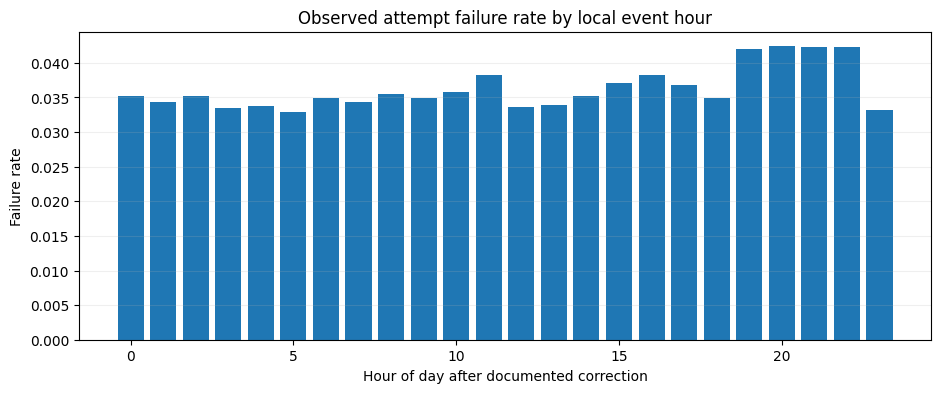

Duplicate station-hour keys: 0


,rows
telemetry_status,
missing,9384
ok,1441341
partial,36987


,station_id,attempts,completed,failures,abandoned,revenue_inr,energy_cost_est,queue_wait_sum,queue_wait_n,failure_rate,...,monthly_rent_inr,monthly_maintenance_inr,grid_tariff_inr_kwh,connectivity_tier,firmware_version,firmware_updated_date,competitor_within_1_5km_since,city_raw,is_test_station,slots_total
18,STN-BLR-019,58067,55255,1691,821,3570935.50,1.086708e+06,14081540,58067,0.029122,...,11342,4641,9.12,good,v3.2.1,2025-04-14,NaN,Bengaluru,False,14
3,STN-BLR-004,52094,49670,1493,700,3231081.40,9.948225e+05,12660599,52094,0.028660,...,12322,5802,9.19,good,v3.2.1,2025-04-14,NaN,Bengaluru,False,16
71,STN-HYD-072,51765,47589,2691,1271,2870922.95,8.449674e+05,12563946,51765,0.051985,...,14597,6364,8.39,good,v3.2.1,2025-04-14,NaN,Hyderabad,False,12
69,STN-HYD-070,49688,45920,2467,1094,2928321.25,9.108667e+05,12072811,49688,0.049650,...,24817,4677,9.19,good,v3.2.0,2025-03-10,NaN,Hyderabad,False,22
42,STN-DEL-043,49597,45326,2754,1306,2802302.45,8.513331e+05,12065768,49597,0.055528,...,16226,6507,8.72,poor,v3.2.1,2025-04-14,NaN,Delhi NCR,False,12
93,STN-JAI-138,48945,44703,2785,1239,2804974.60,9.112600e+05,11915153,48945,0.056901,...,14392,4667,9.27,poor,v3.2.1,2025-04-14,NaN,Jaipur,False,12
49,STN-DEL-050,47060,43007,2647,1202,2639130.25,7.389133e+05,11390604,47060,0.056247,...,21281,5342,8.31,poor,v3.2.1,2025-04-14,NaN,Delhi NCR,False,12
135,STN-PUN-096,46174,43872,1403,708,2964613.20,9.529300e+05,11191730,46174,0.030385,...,11280,5163,10.32,good,v3.2.1,2025-04-14,NaN,Pune,False,16
64,STN-HYD-065,46001,42650,2169,975,2597473.60,7.958583e+05,11157440,46001,0.047151,...,18393,4996,8.98,good,v3.2.1,2025-04-14,NaN,Hyderabad,False,16
96,STN-JAI-141,45594,41613,2581,1215,2528249.90,7.528315e+05,11112812,45594,0.056608,...,16435,5066,8.57,good,v3.2.1,2025-04-14,NaN,Jaipur,False,16


In [7]:
display(city_kpi.sort_values('failure_rate',ascending=False).head(15))
display(hour_kpi.sort_values('event_hour'))
fig,ax=plt.subplots(figsize=(11,4)); ax.bar(hour_kpi.event_hour,hour_kpi.failure_rate); ax.set(xlabel='Hour of day after documented correction',ylabel='Failure rate',title='Observed attempt failure rate by local event hour'); ax.grid(axis='y',alpha=.2); plt.show()

# Read station-hour table, normalize timestamps, and validate intended composite key.
tele = pd.read_csv(DATA_DIR/'station_hourly_status.csv', low_memory=False)
tele['hour_start']=pd.to_datetime(tele.hour_start,errors='coerce').dt.floor('h')
duptele=tele.duplicated(['station_id','hour_start']).sum()
print('Duplicate station-hour keys:',int(duptele))
tele['telemetry_observed']=tele.telemetry_status.ne('missing')
tele_obs=tele.loc[tele.telemetry_observed].copy()
display(tele.groupby('telemetry_status',dropna=False).size().rename('rows').to_frame())
# Station demand/capacity context; capacity is rated 2W+3W slots (not inventory target).
station_stats=station_kpi.merge(stations,on='station_id',how='left',validate='one_to_one')
station_stats['slots_total']=station_stats.slots_2w.fillna(0)+station_stats.slots_3w.fillna(0)
display(station_stats.sort_values('attempts',ascending=False).head(20))


### Station-hour demand and telemetry join

Expected grain is one station × hour. Swap events are aggregated to this grain after timestamp correction; telemetry is checked for one row per station-hour. A left join preserves event-hours without telemetry, and an explicit status filter excludes `missing` readings from operational comparisons. Inventory pressure is normalized as observed charged packs divided by the station's configured 2W+3W inventory target; demand pressure is attempts per configured swap slot. These are descriptive proxies, not causal measures.

Station-hour join: {'event_hours_before': 1033162, 'rows_after': 1033162, 'matched': 1033162, 'unmatched_event_hours': 0, 'telemetry_rows': 1487712, 'telemetry_key_duplicates': 0}
Telemetry statuses for joined event-hours:


,station_hours
telemetry_status,
ok,1000396
partial,26042
missing,6724


Usable-status event-hours with a calculable charged-stock/target ratio: 464818 of 1026438


,demand_quartile,station_hours,attempts,failures,failure_rate,queue_wait_sec,mean_attempts_per_slot_hour,mean_charged_inventory_ratio,mean_outage_minutes
0,Q1 low,256610,267339,9715,0.036340,243.506884,0.065242,0.363082,0.010756
1,Q2,256609,536652,19070,0.035535,243.237576,0.137687,0.344533,0.012159
2,Q3,256609,1014534,37538,0.037000,242.931398,0.262883,0.329974,0.010989
3,Q4 high,256610,1970795,76835,0.038987,242.847735,0.626101,0.325429,0.013561


,inventory_quartile,station_hours,attempts,failures,failure_rate,queue_wait_sec,mean_attempts_per_slot_hour,mean_charged_inventory_ratio,mean_outage_minutes
0,Q1 low,116205,434080,18668,0.043006,242.913321,0.231321,0.175277,0.037176
1,Q2,116204,421715,14754,0.034986,242.990871,0.222386,0.280925,0.000516
2,Q3,116204,403065,14255,0.035367,243.208832,0.200144,0.367215,0.000000
3,Q4 high,116205,389238,13758,0.035346,243.467542,0.183658,0.551306,0.000000
4,NaN,561620,2141222,81723,0.038167,243.119110,0.325617,NaN,0.013888


,city,station_hours,attempts,failures,failure_rate,queue_wait_sec,mean_attempts_per_slot_hour,mean_charged_inventory_ratio,mean_outage_minutes
3,Jaipur,122021,482788,24446,0.050635,243.538964,0.296938,0.297338,0.012293
1,Delhi NCR,204321,761731,35846,0.047059,243.143838,0.293251,0.373135,0.010865
2,Hyderabad,183742,710117,30336,0.042720,242.945336,0.275127,0.348333,0.005551
5,Pune,152541,549328,17003,0.030952,243.020972,0.228666,0.340059,0.010620
0,Bengaluru,217761,759037,21189,0.027916,243.004158,0.282696,0.359352,0.006613
4,Mumbai,146052,526319,14338,0.027242,243.309098,0.253690,0.312915,0.029989


,station_id,city,location_type,station_hours,attempts,failures,queue_wait_sec,mean_attempts_per_slot_hour,mean_charged_inventory_ratio,mean_outage_minutes,failure_rate
36,STN-DEL-037,Delhi NCR,commercial_hub,9039,30838,1823,241.722891,0.213229,NaN,0.019914,0.059115
93,STN-JAI-138,Jaipur,market,9621,46948,2707,243.623291,0.406645,NaN,0.000000,0.057660
47,STN-DEL-048,Delhi NCR,market,9086,34646,1991,244.961680,0.238320,NaN,0.013207,0.057467
44,STN-DEL-045,Delhi NCR,commercial_hub,8983,32237,1830,244.533960,0.224292,NaN,0.006679,0.056767
91,STN-JAI-136,Jaipur,transit_hub,8993,29340,1663,241.440607,0.233038,0.208515,0.020016,0.056680
96,STN-JAI-141,Jaipur,commercial_hub,9926,45594,2581,245.054336,0.287087,NaN,0.024179,0.056608
92,STN-JAI-137,Jaipur,commercial_hub,10014,44371,2498,241.598284,0.553862,NaN,0.017975,0.056298
49,STN-DEL-050,Delhi NCR,commercial_hub,9517,45154,2533,242.651414,0.395380,NaN,0.006305,0.056097
95,STN-JAI-140,Jaipur,commercial_hub,9935,44115,2468,243.352274,0.277523,NaN,0.006039,0.055945
38,STN-DEL-039,Delhi NCR,residential,9280,31783,1764,240.648911,0.285408,NaN,0.000000,0.055501


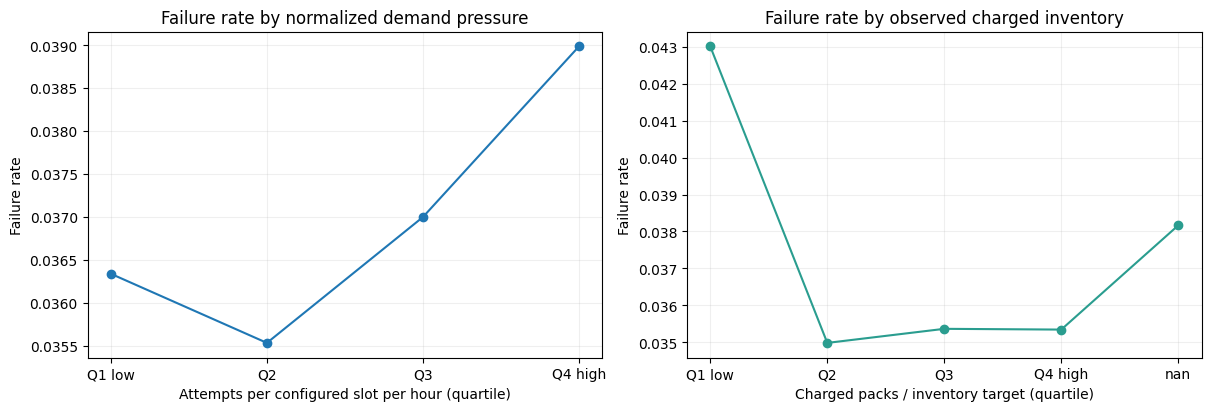

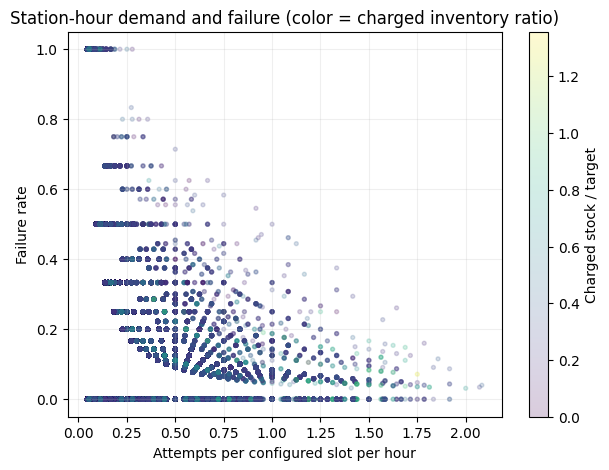

In [8]:
# Consolidate per-chunk event summaries to unique station-hour grain.
event_station_hour=pd.concat(station_hour_parts,ignore_index=True).groupby(['station_id','station_hour'],as_index=False).sum(numeric_only=True)
event_station_hour['failure_rate']=event_station_hour.failures/event_station_hour.attempts
event_station_hour['mean_queue_wait_sec']=event_station_hour.queue_wait_sum/event_station_hour.queue_wait_n.replace(0,np.nan)
tele=pd.read_csv(DATA_DIR/'station_hourly_status.csv',low_memory=False)
tele['station_hour']=pd.to_datetime(tele.hour_start,format='%Y-%m-%d %H:%M:%S',errors='coerce').dt.floor('h')
if tele.duplicated(['station_id','station_hour']).any():
    raise ValueError('Telemetry station-hour key is not unique; refusing many-to-many join.')
if event_station_hour.duplicated(['station_id','station_hour']).any():
    raise ValueError('Aggregated swap station-hour key is not unique.')
before=len(event_station_hour)
station_hour=event_station_hour.merge(tele,on=['station_id','station_hour'],how='left',validate='one_to_one',indicator=True)
print('Station-hour join:',{'event_hours_before':before,'rows_after':len(station_hour),'matched':int(station_hour._merge.eq('both').sum()),'unmatched_event_hours':int(station_hour._merge.eq('left_only').sum()),'telemetry_rows':len(tele),'telemetry_key_duplicates':0})
station_hour=station_hour.drop(columns='_merge').merge(stations[['station_id','city','location_type','host_type','slots_2w','slots_3w','inventory_target_2w','inventory_target_3w']],on='station_id',how='left',validate='many_to_one')
station_hour['slots_total']=station_hour.slots_2w.fillna(0)+station_hour.slots_3w.fillna(0)
station_hour['inventory_target_total']=station_hour.inventory_target_2w+station_hour.inventory_target_3w
station_hour['charged_stock_observed']=station_hour.charged_2w_min+station_hour.charged_3w_min
station_hour['charged_inventory_ratio']=station_hour.charged_stock_observed/station_hour.inventory_target_total.replace(0,np.nan)
station_hour['attempts_per_slot_hour']=station_hour.attempts/station_hour.slots_total.replace(0,np.nan)
usable=station_hour[station_hour.telemetry_status.isin(['ok','partial'])].copy()
print('Telemetry statuses for joined event-hours:')
display(station_hour.telemetry_status.value_counts(dropna=False).rename_axis('telemetry_status').to_frame('station_hours'))
print('Usable-status event-hours with a calculable charged-stock/target ratio:',int(usable.charged_inventory_ratio.notna().sum()),'of',len(usable))
def pressure_summary(data,key):
    return data.groupby(key,observed=True,dropna=False).agg(station_hours=('station_id','size'),attempts=('attempts','sum'),failures=('failures','sum'),failure_rate=('failures','sum'),queue_wait_sec=('mean_queue_wait_sec','mean'),mean_attempts_per_slot_hour=('attempts_per_slot_hour','mean'),mean_charged_inventory_ratio=('charged_inventory_ratio','mean'),mean_outage_minutes=('outage_minutes','mean')).assign(failure_rate=lambda d:d.failures/d.attempts).reset_index()
usable['demand_quartile']=pd.qcut(usable.attempts_per_slot_hour.rank(method='first'),4,labels=['Q1 low','Q2','Q3','Q4 high'])
usable['inventory_quartile']=pd.qcut(usable.charged_inventory_ratio.rank(method='first'),4,labels=['Q1 low','Q2','Q3','Q4 high'])
demand_pressure=pressure_summary(usable,'demand_quartile')
inventory_pressure=pressure_summary(usable,'inventory_quartile')
city_pressure=pressure_summary(usable,'city')
demand_pressure.to_csv(OUT/'station_hour_by_demand_pressure.csv',index=False)
inventory_pressure.to_csv(OUT/'station_hour_by_inventory_pressure.csv',index=False)
city_pressure.to_csv(OUT/'station_hour_by_city.csv',index=False)
station_pressure=usable.groupby(['station_id','city','location_type'],dropna=False).agg(station_hours=('station_hour','size'),attempts=('attempts','sum'),failures=('failures','sum'),queue_wait_sec=('mean_queue_wait_sec','mean'),mean_attempts_per_slot_hour=('attempts_per_slot_hour','mean'),mean_charged_inventory_ratio=('charged_inventory_ratio','mean'),mean_outage_minutes=('outage_minutes','mean')).reset_index()
station_pressure['failure_rate']=station_pressure.failures/station_pressure.attempts
station_pressure=station_pressure[station_pressure.station_hours.ge(100)]
station_pressure.to_csv(OUT/'station_operational_pressure.csv',index=False)
display(demand_pressure); display(inventory_pressure); display(city_pressure.sort_values('failure_rate',ascending=False))
display(station_pressure.sort_values(['failure_rate','mean_attempts_per_slot_hour'],ascending=False).head(15))
fig,ax=plt.subplots(1,2,figsize=(12,4),constrained_layout=True)
ax[0].plot(demand_pressure.demand_quartile.astype(str),demand_pressure.failure_rate,marker='o'); ax[0].set(xlabel='Attempts per configured slot per hour (quartile)',ylabel='Failure rate',title='Failure rate by normalized demand pressure')
ax[1].plot(inventory_pressure.inventory_quartile.astype(str),inventory_pressure.failure_rate,marker='o',color='#2a9d8f'); ax[1].set(xlabel='Charged packs / inventory target (quartile)',ylabel='Failure rate',title='Failure rate by observed charged inventory')
for a in ax:a.grid(alpha=.2)
plt.show()
fig,ax=plt.subplots(figsize=(7,5)); ax.scatter(usable.attempts_per_slot_hour,usable.failure_rate,c=usable.charged_inventory_ratio,cmap='viridis',alpha=.2,s=8); ax.set(xlabel='Attempts per configured slot per hour',ylabel='Failure rate',title='Station-hour demand and failure (color = charged inventory ratio)'); ax.grid(alpha=.2); fig.colorbar(ax.collections[0],ax=ax,label='Charged stock / target'); plt.show()


## 10. Station & Geographic Analysis

Station comparisons include volume, failures, queues, capacity, station characteristics and costs. A raw ranking is descriptive only: station demand, city, operating age, telemetry completeness and vehicle mix differ. Expansion-wave differences are unadjusted associations; absent a suitable comparison design, no treatment effect is claimed.

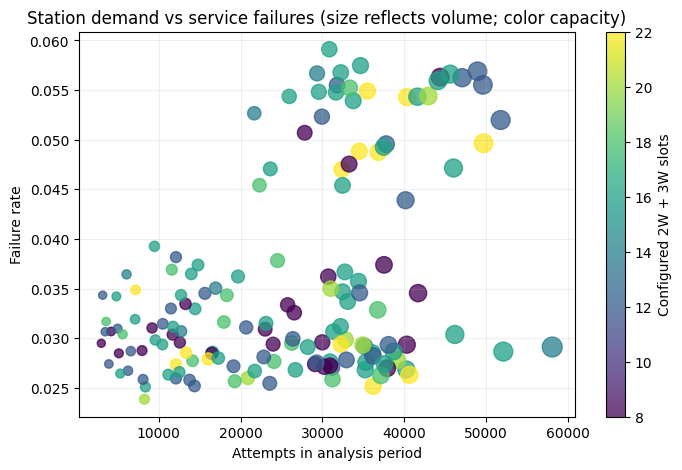

,city,expansion_wave,stations,attempts,failures,completed,failure_rate
0,Bengaluru,Launch,20,639093,17973,609852,0.028123
1,Bengaluru,Wave1_2024H2,6,85304,2229,81596,0.026130
2,Bengaluru,Wave2_2025H1,6,38899,1115,37115,0.028664
3,Delhi NCR,Launch,18,623530,31283,574804,0.050171
4,Delhi NCR,Wave1_2024H2,6,88049,2918,83389,0.033141
5,Delhi NCR,Wave2_2025H1,6,57334,1996,54192,0.034814
6,Hyderabad,Launch,16,573730,26170,533035,0.045614
7,Hyderabad,Wave1_2024H2,5,90762,2868,86125,0.031599
8,Hyderabad,Wave2_2025H1,5,47438,1389,45152,0.029280
9,Jaipur,Launch,10,376135,20880,343900,0.055512


In [9]:
if len(station_stats):
    fig,ax=plt.subplots(figsize=(8,5)); z=station_stats.dropna(subset=['attempts','failure_rate']); s=ax.scatter(z.attempts,z.failure_rate,c=z.slots_total,s=25+z.attempts/z.attempts.max()*180,cmap='viridis',alpha=.75); ax.set(xlabel='Attempts in analysis period',ylabel='Failure rate',title='Station demand vs service failures (size reflects volume; color capacity)'); fig.colorbar(s,ax=ax,label='Configured 2W + 3W slots'); ax.grid(alpha=.2); plt.show()
    station_stats.groupby(['city','expansion_wave'],dropna=False).agg(stations=('station_id','nunique'),attempts=('attempts','sum'),failures=('failures','sum'),completed=('completed','sum')).assign(failure_rate=lambda d:d.failures/d.attempts).reset_index().to_csv(OUT/'expansion_wave_summary.csv',index=False)
display(station_stats.groupby(['city','expansion_wave'],dropna=False).agg(stations=('station_id','nunique'),attempts=('attempts','sum'),failures=('failures','sum'),completed=('completed','sum')).assign(failure_rate=lambda d:d.failures/d.attempts).reset_index())


## 11. Battery & Equipment Analysis

Delivered SOH summaries join completed-swap battery-out identifiers to the battery registry. Comparisons show sample sizes and segment by pack type and age band where possible. Supplier averages alone are not treated as supplier quality effects. Readings above 100% are counted in the audit and clipped to 100 only for bounded percentage visualizations; raw values remain available in the event output.

,supplier,pack_type,age_band,batteries,swaps,mean_delivered_soh
0,Amptek,2W_2.1kWh,<=6mo,382,245881,89.438074
1,Amptek,2W_2.1kWh,6-12mo,436,280514,89.495165
2,Amptek,2W_2.1kWh,1-2y,280,179690,89.496882
3,Amptek,3W_4.8kWh,<=6mo,72,27068,93.003532
4,Amptek,3W_4.8kWh,6-12mo,85,32103,92.953740
5,Amptek,3W_4.8kWh,1-2y,52,19702,92.940871
6,Cellora,2W_2.1kWh,<=6mo,531,341341,89.464181
7,Cellora,2W_2.1kWh,6-12mo,671,431707,89.506255
8,Cellora,2W_2.1kWh,1-2y,1382,889092,89.468739
9,Cellora,2W_2.1kWh,>2y,451,289821,89.484898


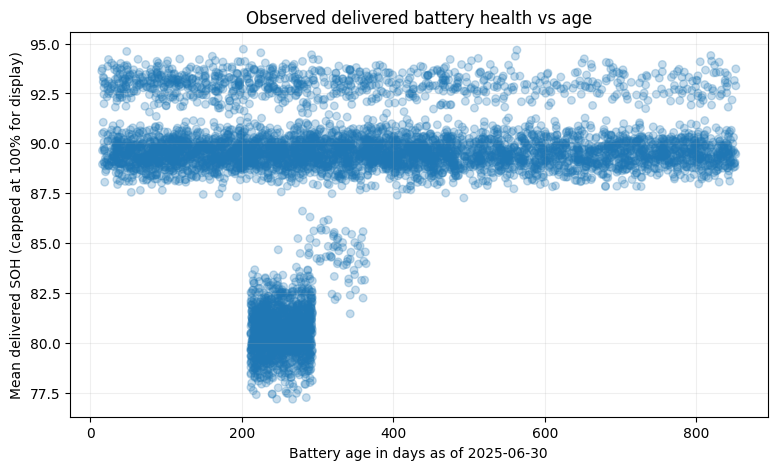

In [10]:
battery_perf=battery_event.merge(batteries,left_on='battery_out_id',right_on='battery_id',how='left',validate='many_to_one')
battery_perf['commission_date']=pd.to_datetime(battery_perf.commission_date,errors='coerce')
battery_perf['age_days_at_analysis']= (pd.Timestamp('2025-06-30')-battery_perf.commission_date).dt.days
battery_perf['age_band']=pd.cut(battery_perf.age_days_at_analysis,[-1,180,365,730,10000],labels=['<=6mo','6-12mo','1-2y','>2y'])
display(battery_perf.groupby(['supplier','pack_type','age_band'],observed=True).agg(batteries=('battery_id','nunique'),swaps=('swaps','sum'),mean_delivered_soh=('delivered_soh','mean')).reset_index().query('swaps >= 30'))
fig,ax=plt.subplots(figsize=(9,5)); bp=battery_perf.dropna(subset=['age_days_at_analysis','delivered_soh']); ax.scatter(bp.age_days_at_analysis,bp.delivered_soh.clip(upper=100),s=np.minimum(bp.swaps,30),alpha=.25); ax.set(xlabel='Battery age in days as of 2025-06-30',ylabel='Mean delivered SOH (capped at 100% for display)',title='Observed delivered battery health vs age'); ax.grid(alpha=.2); plt.show()


## 12. Pricing & Fleet Economics

This focused pass uses the source transaction columns `list_price_inr`, `discount_inr`, `amount_charged_inr`, and `energy_to_recharge_kwh`. Realized discount exposure comes from `discount_inr`; partner contract rates are shown separately and never substituted for realized discounts. Rider, partner, and station keys are checked before attribution. The estimated contribution proxy reuses the existing formula (charged revenue less estimated recharge electricity cost); it is not contribution margin and excludes labor, battery depreciation, fixed station costs, fees, and other costs.

{'source_rows': 3877013,
 'excluded_test_station_rows': 62031,
 'analysis_window_rows': 3814982,
 'event_rows_after_rider_join': 3814982,
 'unmatched_rider_event_rows': 0,
 'unmatched_station_rows': 0,
 'firmware_timestamps_corrected': 141280,
 'completed_missing_list_price': 0,
 'completed_missing_discount': 0,
 'completed_missing_charge': 0,
 'rider_dimension_rows': 20000,
 'unique_rider_ids': 20000,
 'partner_master_rows': 12,
 'unique_partner_ids': 12,
 'riders_matched_to_partner_master': 12372,
 'riders_without_partner_id': 7628,
 'riders_with_unknown_nonnull_partner_id': 0}

,tariff_code,analysis_attempts,analysis_completed,charged_revenue_inr,avg_charge_per_completed_swap,actual_discount_inr,realized_discount_rate,estimated_contribution_proxy_per_completed_swap
1,PARTNER,2521737,2368154,146079774.5,61.685082,20875332.5,0.12647,41.509483
3,STD,1085161,1019766,67519860.0,66.211131,0.0,0.00000,47.876020
2,PEAK,171696,163922,13523775.0,82.501281,0.0,0.00000,65.187304
0,OFFPEAK,36388,34833,2071886.0,59.480550,0.0,0.00000,42.164497


,partner_attribution,partner_id,attempts,completed,charged_revenue_inr,actual_discount_inr,realized_discount_rate,active_contract_discount_pct,estimated_contribution_proxy_per_completed_swap
12,Unassigned rider partner,NaN,1293245,1218521,83115521.00,0.00,0.000000,NaN,50.041556
0,FeastFly,FP-01,549133,516367,32027884.50,3429955.50,0.100000,10.0,43.814128
2,ZipDrop,FP-03,583937,549390,28606514.80,8033300.20,0.219251,28.0,32.928618
1,ParcelNest,FP-02,312702,296209,16740212.75,2945483.25,0.150000,15.0,38.384604
4,Swiggle Go,FP-05,252273,237632,14092428.90,1741741.10,0.110000,11.0,40.940016
3,CargoTuk,FP-04,146011,131334,13062630.80,1134503.20,0.080000,8.0,58.664352
6,QuickCart,FP-07,135718,127961,7934508.55,757764.45,0.090000,9.0,44.121826
5,RideMitra,FP-06,126484,119503,7494595.50,473170.50,0.060000,6.0,44.777254
7,DabbaXpress,FP-08,97697,92027,5853723.60,489558.40,0.080000,8.0,45.550527
8,HaulKing,FP-09,59159,53120,5331093.20,400955.80,0.070000,7.0,59.593029


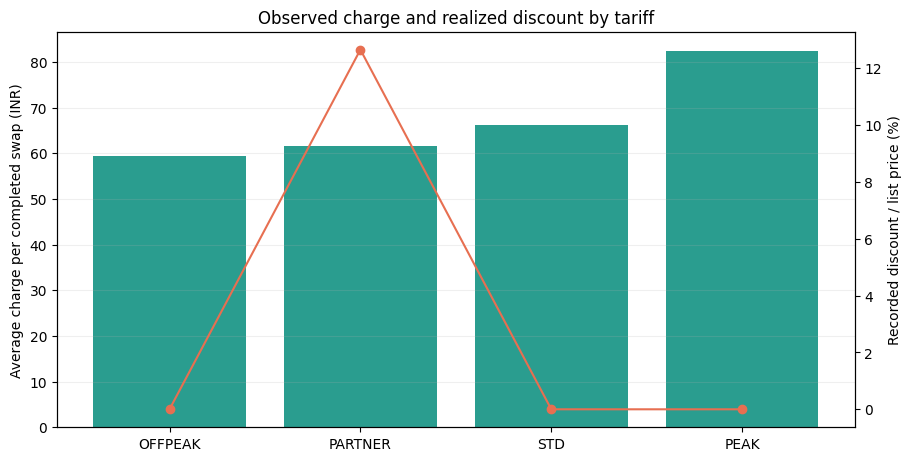

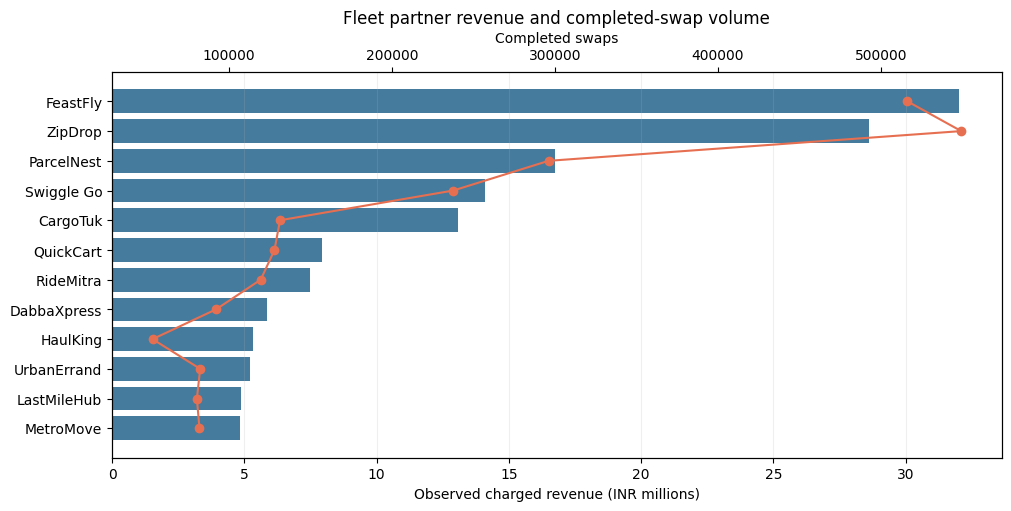

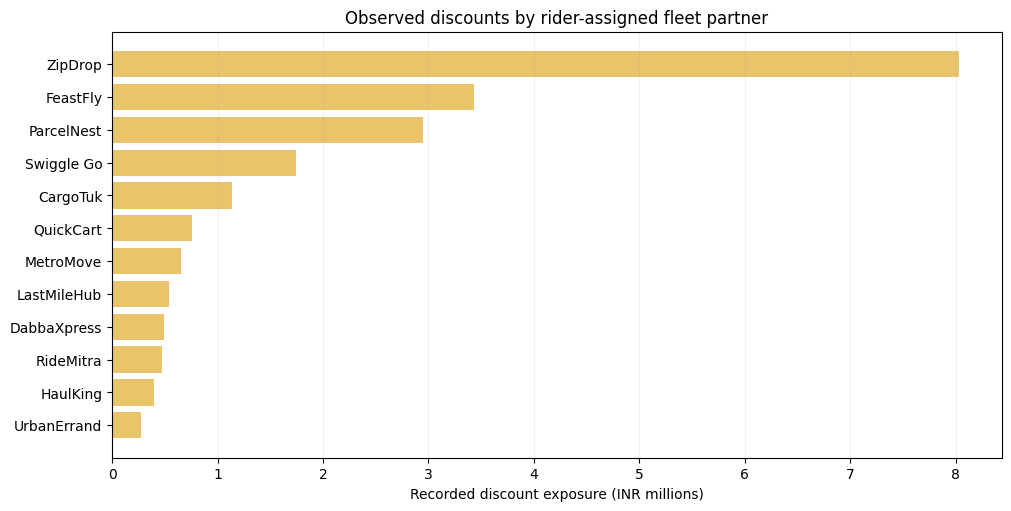

In [11]:
# Validate all dimension keys and partner mapping before attributing transaction volume or revenue.
for frame,key,label in [(riders,'rider_id','riders'),(partners,'partner_id','fleet_partners'),(stations,'station_id','stations')]:
    if frame[key].duplicated().any(): raise ValueError(f'{label}.{key} is not unique; refusing partner/economics join.')
partner_master=riders[['rider_id','partner_id']].merge(
    partners[['partner_id','partner_name','partner_segment','contract_type','discount_pct','amendment_date','discount_pct_after_amendment']],
    on='partner_id',how='left',validate='many_to_one',indicator='partner_master_join')
if partner_master.rider_id.duplicated().any(): raise ValueError('Partner rider map is not unique by rider_id.')
partner_join_audit={
    'riders':len(riders),'unique_rider_ids':int(riders.rider_id.nunique()),
    'partner_keys':len(partners),'unique_partner_ids':int(partners.partner_id.nunique()),
    'riders_with_partner_metadata':int(partner_master.partner_master_join.eq('both').sum()),
    'riders_without_partner_id':int(partner_master.partner_id.isna().sum()),
    'riders_with_unknown_partner_id':int((partner_master.partner_id.notna() & partner_master.partner_name.isna()).sum()),
}
if partner_join_audit['riders']!=partner_join_audit['unique_rider_ids'] or partner_join_audit['partner_keys']!=partner_join_audit['unique_partner_ids']:
    raise ValueError('Dimension key validation failed.')
partner_master['partner_attribution']=np.where(
    partner_master.partner_id.isna(),'Unassigned rider partner',
    np.where(partner_master.partner_name.isna(),'Unknown partner ID',partner_master.partner_name))
partner_master=partner_master.drop(columns='partner_master_join')
grid_rate=stations.set_index('station_id').grid_tariff_inr_kwh
pricing_cols=['event_id','rider_id','station_id','event_ts','event_type','station_firmware','tariff_code',
              'list_price_inr','discount_inr','amount_charged_inr','energy_to_recharge_kwh']
pricing_tariff_parts=[]; fleet_econ_parts=[]
pricing_join_audit={'source_rows':0,'excluded_test_station_rows':0,'analysis_window_rows':0,
                    'event_rows_after_rider_join':0,'unmatched_rider_event_rows':0,'unmatched_station_rows':0,
                    'firmware_timestamps_corrected':0,'completed_missing_list_price':0,
                    'completed_missing_discount':0,'completed_missing_charge':0}
pricing_join_audit.update({
    'rider_dimension_rows':len(riders),'unique_rider_ids':int(riders.rider_id.nunique()),
    'partner_master_rows':len(partners),'unique_partner_ids':int(partners.partner_id.nunique()),
    'riders_matched_to_partner_master':partner_join_audit['riders_with_partner_metadata'],
    'riders_without_partner_id':partner_join_audit['riders_without_partner_id'],
    'riders_with_unknown_nonnull_partner_id':partner_join_audit['riders_with_unknown_partner_id']})
def economics_aggregate(frame,group_keys):
    d=frame.copy()
    d['completed']=d.event_type.eq('swap_completed')
    d['failed']=d.event_type.str.contains('fail',case=False,na=False)
    d['completed_list_price']=d.list_price_inr.where(d.completed)
    d['completed_discount']=d.discount_inr.where(d.completed)
    d['completed_charge']=d.amount_charged_inr.where(d.completed)
    d['completed_charge_count']=(d.completed & d.amount_charged_inr.notna()).astype('int64')
    d['discounted_completed_count']=(d.completed & d.discount_inr.gt(0)).astype('int64')
    return d.groupby(group_keys,dropna=False,observed=True).agg(
        attempts=('event_id','size'),completed=('completed','sum'),failures=('failed','sum'),
        list_price_inr=('completed_list_price','sum'),actual_discount_inr=('completed_discount','sum'),
        charged_revenue_inr=('completed_charge','sum'),completed_with_charge=('completed_charge_count','sum'),
        discounted_completed_swaps=('discounted_completed_count','sum'),
        energy_cost_est=('energy_cost_est','sum')).reset_index()

for raw in pd.read_csv(DATA_DIR/'swap_events.csv',usecols=pricing_cols,chunksize=CHUNK,low_memory=False):
    pricing_join_audit['source_rows']+=len(raw)
    test_station=raw.station_id.astype(str).str.startswith('STN-TST')
    pricing_join_audit['excluded_test_station_rows']+=int(test_station.sum())
    raw=raw.loc[~test_station].copy()
    raw['event_ts']=pd.to_datetime(raw.event_ts,errors='coerce')
    fw=raw.station_firmware.eq('v3.2.0') & raw.event_ts.ge('2025-03-09 18:30:00') & raw.event_ts.lt('2025-04-14 18:30:00')
    raw.loc[fw,'event_ts']+=pd.Timedelta(hours=5,minutes=30)
    pricing_join_audit['firmware_timestamps_corrected']+=int(fw.sum())
    raw=raw.loc[raw.event_ts.ge('2024-01-01') & raw.event_ts.lt('2025-07-01')].copy()
    pricing_join_audit['analysis_window_rows']+=len(raw)
    if raw.empty: continue
    completed=raw.event_type.eq('swap_completed')
    pricing_join_audit['completed_missing_list_price']+=int((completed & raw.list_price_inr.isna()).sum())
    pricing_join_audit['completed_missing_discount']+=int((completed & raw.discount_inr.isna()).sum())
    pricing_join_audit['completed_missing_charge']+=int((completed & raw.amount_charged_inr.isna()).sum())
    raw['grid_tariff_inr_kwh']=raw.station_id.map(grid_rate)
    pricing_join_audit['unmatched_station_rows']+=int(raw.grid_tariff_inr_kwh.isna().sum())
    raw['energy_cost_est']=raw.energy_to_recharge_kwh*raw.grid_tariff_inr_kwh
    pricing_tariff_parts.append(economics_aggregate(raw,'tariff_code'))
    joined=raw.merge(partner_master[['rider_id','partner_id','partner_name','partner_segment','contract_type','discount_pct','amendment_date','discount_pct_after_amendment','partner_attribution']],on='rider_id',how='left',validate='many_to_one',indicator='_rider_join')
    pricing_join_audit['event_rows_after_rider_join']+=len(joined)
    pricing_join_audit['unmatched_rider_event_rows']+=int(joined._rider_join.eq('left_only').sum())
    joined['partner_attribution']=joined.partner_attribution.fillna('Unmatched rider ID')
    fleet_econ_parts.append(economics_aggregate(joined,['partner_id','partner_attribution']))

if pricing_join_audit['analysis_window_rows']!=pricing_join_audit['event_rows_after_rider_join']:
    raise ValueError('Rider join changed event row count; refusing partner metrics.')
if pricing_join_audit['unmatched_rider_event_rows'] or pricing_join_audit['unmatched_station_rows']:
    raise ValueError(f'Unmatched pricing keys found: {pricing_join_audit}')
if pricing_join_audit['completed_missing_list_price'] or pricing_join_audit['completed_missing_discount'] or pricing_join_audit['completed_missing_charge']:
    print('Completed transaction price/discount fields missing:',{k:v for k,v in pricing_join_audit.items() if k.startswith('completed_missing_')})
def combine_economics(parts,keys):
    z=pd.concat(parts,ignore_index=True); metrics=[c for c in z if c not in keys]
    return z.groupby(keys,dropna=False,as_index=False)[metrics].sum(min_count=1)
pricing_tariff=combine_economics(pricing_tariff_parts,['tariff_code'])
fleet_partner_econ=combine_economics(fleet_econ_parts,['partner_id','partner_attribution'])
amendment=pd.to_datetime(partners.amendment_date,errors='coerce')
after=pd.to_numeric(partners.discount_pct_after_amendment,errors='coerce')
base=pd.to_numeric(partners.discount_pct,errors='coerce')
as_of=pd.Timestamp('2025-06-30 23:59:59')
partner_terms=partners[['partner_id','partner_name','partner_segment','contract_type']].copy()
partner_terms['active_contract_discount_pct']=np.where(amendment.le(as_of)&after.notna(),after,base)
fleet_partner_econ=fleet_partner_econ.merge(partner_terms,on='partner_id',how='left',validate='many_to_one')
fleet_partner_econ['realized_discount_rate']=fleet_partner_econ.actual_discount_inr/fleet_partner_econ.list_price_inr.replace(0,np.nan)
fleet_partner_econ['avg_charge_per_completed_swap']=fleet_partner_econ.charged_revenue_inr/fleet_partner_econ.completed_with_charge.replace(0,np.nan)
fleet_partner_econ['revenue_per_completed_swap']=fleet_partner_econ.avg_charge_per_completed_swap
fleet_partner_econ['revenue_per_attempt']=fleet_partner_econ.charged_revenue_inr/fleet_partner_econ.attempts.replace(0,np.nan)
fleet_partner_econ['charge_reconciliation_diff_inr']=fleet_partner_econ.list_price_inr-fleet_partner_econ.actual_discount_inr-fleet_partner_econ.charged_revenue_inr

# Reuse the existing notebook tariff counts, revenue and energy-cost proxy, validating exact grain/count alignment.
if 'tariff_kpi' in globals():
    pricing_tariff=pricing_tariff.merge(tariff_kpi[['tariff_code','attempts','completed','revenue_inr','energy_cost_est']],on='tariff_code',how='outer',validate='one_to_one',indicator='_existing_kpi_join')
    if not pricing_tariff._existing_kpi_join.eq('both').all(): raise ValueError('New tariff metrics do not align with existing tariff KPI grain.')
    if not pricing_tariff.attempts_x.equals(pricing_tariff.attempts_y) or not pricing_tariff.completed_x.equals(pricing_tariff.completed_y): raise ValueError('Tariff attempts/completions do not reconcile to existing notebook KPIs.')
    if not np.allclose(pricing_tariff.energy_cost_est_x,pricing_tariff.energy_cost_est_y,rtol=1e-9,atol=.01): raise ValueError('Energy cost does not reconcile to existing notebook calculation.')
    if not np.allclose(pricing_tariff.charged_revenue_inr,pricing_tariff.revenue_inr,rtol=1e-9,atol=.01): raise ValueError('Completed-swap charges do not reconcile to existing tariff revenue.')
    pricing_tariff=pricing_tariff.drop(columns='_existing_kpi_join')
    pricing_tariff['analysis_energy_cost_est']=pricing_tariff.energy_cost_est_y
    pricing_tariff['analysis_completed']=pricing_tariff.completed_y
    pricing_tariff['analysis_attempts']=pricing_tariff.attempts_y
    pricing_tariff['analysis_revenue_inr']=pricing_tariff.revenue_inr
else:
    pricing_tariff['analysis_energy_cost_est']=pricing_tariff.energy_cost_est
    pricing_tariff['analysis_completed']=pricing_tariff.completed
    pricing_tariff['analysis_attempts']=pricing_tariff.attempts
    pricing_tariff['analysis_revenue_inr']=pricing_tariff.charged_revenue_inr
pricing_tariff['estimated_contribution_proxy_inr']=pricing_tariff.analysis_revenue_inr-pricing_tariff.analysis_energy_cost_est
pricing_tariff['estimated_contribution_proxy_per_completed_swap']=pricing_tariff.estimated_contribution_proxy_inr/pricing_tariff.analysis_completed.replace(0,np.nan)
pricing_tariff['avg_charge_per_completed_swap']=pricing_tariff.charged_revenue_inr/pricing_tariff.completed_with_charge.replace(0,np.nan)
pricing_tariff['revenue_per_completed_swap']=pricing_tariff.avg_charge_per_completed_swap
pricing_tariff['realized_discount_rate']=pricing_tariff.actual_discount_inr/pricing_tariff.list_price_inr.replace(0,np.nan)
pricing_tariff['revenue_per_attempt']=pricing_tariff.charged_revenue_inr/pricing_tariff.analysis_attempts.replace(0,np.nan)
pricing_tariff['actual_discount_per_completed_swap']=pricing_tariff.actual_discount_inr/pricing_tariff.analysis_completed.replace(0,np.nan)
pricing_tariff['charge_reconciliation_diff_inr']=pricing_tariff.list_price_inr-pricing_tariff.actual_discount_inr-pricing_tariff.charged_revenue_inr
fleet_partner_econ['estimated_contribution_proxy_inr']=fleet_partner_econ.charged_revenue_inr-fleet_partner_econ.energy_cost_est
fleet_partner_econ['estimated_contribution_proxy_per_completed_swap']=fleet_partner_econ.estimated_contribution_proxy_inr/fleet_partner_econ.completed.replace(0,np.nan)
if not np.isclose(fleet_partner_econ.charged_revenue_inr.sum(),pricing_tariff.charged_revenue_inr.sum(),rtol=1e-9,atol=.01): raise ValueError('Partner-assigned plus unassigned revenue does not reconcile to tariff revenue.')
pricing_tariff.to_csv(OUT/'pricing_tariff_performance.csv',index=False)
fleet_partner_econ.to_csv(OUT/'fleet_partner_economics.csv',index=False)
display(pricing_join_audit)
display(pricing_tariff[['tariff_code','analysis_attempts','analysis_completed','charged_revenue_inr','avg_charge_per_completed_swap','actual_discount_inr','realized_discount_rate','estimated_contribution_proxy_per_completed_swap']].sort_values('charged_revenue_inr',ascending=False))
display(fleet_partner_econ[['partner_attribution','partner_id','attempts','completed','charged_revenue_inr','actual_discount_inr','realized_discount_rate','active_contract_discount_pct','estimated_contribution_proxy_per_completed_swap']].sort_values('charged_revenue_inr',ascending=False))

# Three focused economics charts.
fig,ax=plt.subplots(figsize=(9,4.5),constrained_layout=True)
plot_tariff=pricing_tariff.sort_values('avg_charge_per_completed_swap')
ax.bar(plot_tariff.tariff_code,plot_tariff.avg_charge_per_completed_swap,color='#2a9d8f')
ax.set(ylabel='Average charge per completed swap (INR)',title='Observed charge and realized discount by tariff')
ax2=ax.twinx(); ax2.plot(plot_tariff.tariff_code,100*plot_tariff.realized_discount_rate,color='#e76f51',marker='o'); ax2.set_ylabel('Recorded discount / list price (%)')
ax.grid(axis='y',alpha=.2); plt.show()
named=fleet_partner_econ[fleet_partner_econ.partner_id.notna()].sort_values('charged_revenue_inr',ascending=False)
fig,ax=plt.subplots(figsize=(10,5),constrained_layout=True)
ax.barh(named.partner_name,named.charged_revenue_inr/1e6,color='#457b9d'); ax.invert_yaxis(); ax.set(xlabel='Observed charged revenue (INR millions)',title='Fleet partner revenue and completed-swap volume')
ax2=ax.twiny(); ax2.plot(named.completed,named.partner_name,color='#e76f51',marker='o'); ax2.set_xlabel('Completed swaps')
ax.grid(axis='x',alpha=.2); plt.show()
discount_plot=named.sort_values('actual_discount_inr',ascending=True)
fig,ax=plt.subplots(figsize=(10,5),constrained_layout=True)
ax.barh(discount_plot.partner_name,discount_plot.actual_discount_inr/1e6,color='#e9c46a'); ax.set(xlabel='Recorded discount exposure (INR millions)',title='Observed discounts by rider-assigned fleet partner'); ax.grid(axis='x',alpha=.2); plt.show()


## 13. Rider Retention & Root Cause Analysis

Transparent primary definition: rider's first completed swap in the analysis window, followed by another completed swap within 7/14/30/60 days. This chunked summary currently retains first event dates and total completions; exact return windows are calculated from event timestamps below using a focused second streaming pass. Results are associations and should be stratified where sample sizes support it.

In [ ]:
# Compact timestamp scan also captures each rider's first attempted event and first completed-swap experience.
_retention_prereqs=['pd','np','riders','stations','tickets','DATA_DIR','CHUNK','OUT']
_missing_retention_prereqs=[name for name in _retention_prereqs if name not in globals()]
if _missing_retention_prereqs: raise RuntimeError('Retention analysis needs earlier setup and analysis cells. In Colab, choose Runtime → Restart session, then Runtime → Run all. Missing: '+', '.join(_missing_retention_prereqs))
rider_profile=riders[['rider_id','home_city','vehicle_class','plan_type']].copy()
if rider_profile.rider_id.duplicated().any(): raise ValueError('rider_profile must contain one row per rider_id before retention attribution.')
# Stop with a clear instruction if this dependent cell is run before data loading.
_retention_prereqs=['pd','np','riders','stations','tickets','DATA_DIR','CHUNK','OUT']
_missing_retention_prereqs=[name for name in _retention_prereqs if name not in globals()]
if _missing_retention_prereqs: raise RuntimeError('Retention analysis needs earlier setup and analysis cells. In Colab, choose Runtime → Restart session, then Runtime → Run all. Missing: '+', '.join(_missing_retention_prereqs))
# Explicitly prepare rider attributes used later by retention segmentation and reporting.
rider_profile = riders[['rider_id', 'home_city', 'vehicle_class', 'plan_type']].copy()
if rider_profile['rider_id'].duplicated().any():
    raise ValueError('rider_profile must contain one row per rider_id before retention attribution.')
ret_parts=[]; first_exp_parts=[]; first_attempt_parts=[]; rider_dtype=pd.CategoricalDtype(categories=riders.rider_id.astype(str))
exp_cols=['rider_id','event_ts','station_id','queue_wait_sec','tariff_code','soh_out_pct']
for ev in pd.read_csv(event_path,chunksize=CHUNK,low_memory=False,usecols=['rider_id','event_ts','event_type','station_id','queue_wait_sec','tariff_code','soh_out_pct']):
    ev=ev.copy()
    ev['event_ts']=pd.to_datetime(ev.event_ts,format='%Y-%m-%d %H:%M:%S',errors='coerce')
    ev=ev[ev.event_ts.ge('2024-01-01') & ev.event_ts.lt('2025-07-01')]
    if len(ev):
        ev['rider_id']=ev.rider_id.astype(str).astype(rider_dtype)
        first_attempt_parts.append(ev.sort_values('event_ts').drop_duplicates('rider_id')[['rider_id','event_ts','event_type']])
        completed=ev[ev.event_type.eq('swap_completed')].copy()
        if len(completed):
            first_exp_parts.append(completed.sort_values('event_ts').drop_duplicates('rider_id')[exp_cols])
            completed['event_ts']=completed.event_ts.astype('int64')
            ret_parts.append(completed[['rider_id','event_ts']])
all_completed=pd.concat(ret_parts,ignore_index=True)
all_completed=all_completed.drop_duplicates(['rider_id','event_ts']).sort_values(['rider_id','event_ts'])
first_ts=all_completed.groupby('rider_id',observed=True).event_ts.min().rename('first_ns')
later=all_completed.join(first_ts,on='rider_id')
later=later[later.event_ts>later.first_ns]
next_ts=later.groupby('rider_id',observed=True).event_ts.min().rename('next_ns')
retention=first_ts.to_frame().join(next_ts).reset_index()
retention['first_completed_ts']=pd.to_datetime(retention.pop('first_ns'))
retention['next_completed_ts']=pd.to_datetime(retention.pop('next_ns'))
observation_end=pd.to_datetime(all_completed.event_ts.max())
for days in [7,14,30,60]:
    retention[f'eligible_{days}d']=retention.first_completed_ts.le(observation_end-pd.Timedelta(days=days))
    delta=(retention.next_completed_ts-retention.first_completed_ts).dt.total_seconds()/86400
    retention[f'return_{days}d']=delta.gt(0)&delta.le(days)&retention[f'eligible_{days}d']
retention=retention.merge(rider_profile,on='rider_id',how='left',validate='one_to_one')
first_exp=pd.concat(first_exp_parts,ignore_index=True).sort_values('event_ts').drop_duplicates('rider_id').rename(columns={'event_ts':'first_completed_ts','station_id':'first_station_id','queue_wait_sec':'first_queue_wait_sec','tariff_code':'first_tariff','soh_out_pct':'first_delivered_soh'})
first_exp=first_exp.merge(stations[['station_id','city','location_type','host_type']],left_on='first_station_id',right_on='station_id',how='left',validate='many_to_one').drop(columns='station_id')
first_attempt=pd.concat(first_attempt_parts,ignore_index=True).sort_values('event_ts').drop_duplicates('rider_id').rename(columns={'event_type':'first_attempt_outcome','event_ts':'first_attempt_ts'})
first_attempt['first_attempt_failed']=first_attempt.first_attempt_outcome.str.contains('fail|abandon|cancel',case=False,na=False)
retention=retention.merge(first_exp,on=['rider_id','first_completed_ts'],how='left',validate='one_to_one').merge(first_attempt,on='rider_id',how='left',validate='one_to_one')
# Support exposure is a rider-level ticket within 7 days after first completed swap.
ticket_dates=tickets[['ticket_id','rider_id','created_ts']].copy(); ticket_dates['created_ts']=pd.to_datetime(ticket_dates.created_ts,errors='coerce')
ticket_link=ticket_dates.merge(retention[['rider_id','first_completed_ts']],on='rider_id',how='inner',validate='many_to_one')
ticket_link=ticket_link[ticket_link.created_ts.ge(ticket_link.first_completed_ts)&ticket_link.created_ts.le(ticket_link.first_completed_ts+pd.Timedelta(days=7))]
support_7d=ticket_link.groupby('rider_id').ticket_id.nunique().gt(0).rename('support_within_7d')
retention=retention.merge(support_7d,on='rider_id',how='left',validate='one_to_one')
retention['support_within_7d']=retention.support_within_7d.fillna(False)
retention['first_attempt_failed']=retention.first_attempt_failed.fillna(False)
eligible_ret=retention[retention.eligible_30d].copy()
queue_median=eligible_ret.first_queue_wait_sec.median()
eligible_ret['first_queue_band']=np.where(eligible_ret.first_queue_wait_sec.isna(),'Missing wait',np.where(eligible_ret.first_queue_wait_sec.le(queue_median),'At/below median wait','Above median wait'))
eligible_ret['first_soh_band']=pd.qcut(eligible_ret.first_delivered_soh.rank(method='first'),4,labels=['Q1 lower','Q2','Q3','Q4 higher'])
def retention_table(data,key):
    return data.groupby(key,dropna=False).agg(riders=('rider_id','nunique'),return_30d=('return_30d','mean')).reset_index().query('riders >= 100')
experience_tables={key:retention_table(eligible_ret,key) for key in ['first_queue_band','first_attempt_failed','city','first_station_id','location_type','vehicle_class','plan_type','first_tariff','first_soh_band','support_within_7d']}
for key,table in experience_tables.items():
    display(table.sort_values('return_30d'))
experience_summary=[]
for key,table in experience_tables.items():
    if len(table)>=2:
        lo=table.loc[table.return_30d.idxmin()]; hi=table.loc[table.return_30d.idxmax()]
        experience_summary.append({'factor':key,'lowest_group':str(lo.iloc[0]),'lowest_n':int(lo.riders),'lowest_return_30d':lo.return_30d,'highest_group':str(hi.iloc[0]),'highest_n':int(hi.riders),'highest_return_30d':hi.return_30d,'absolute_gap_pp':100*(hi.return_30d-lo.return_30d)})
experience_summary=pd.DataFrame(experience_summary)
experience_summary.to_csv(OUT/'first_experience_retention_summary.csv',index=False)
display(experience_summary)
print('Riders with first completed swap:',len(retention),'; observation end:',observation_end)
display(pd.DataFrame([{'window_days':d,'eligible_riders':int(retention[f'eligible_{d}d'].sum()),'observed_return_rate':retention.loc[retention[f'eligible_{d}d'],f'return_{d}d'].mean()} for d in [7,14,30,60]]))
display(retention.loc[retention.eligible_30d].groupby(['home_city','vehicle_class','plan_type'],dropna=False).agg(riders=('rider_id','size'),return_30d=('return_30d','mean')).reset_index().query('riders >= 30').sort_values('return_30d'))


## 14. Cross-Domain Root Cause Synthesis

Only sufficiently sampled and calculated associations are surfaced. Joining rider experience to first swap and tickets is an association analysis, vulnerable to selection, exposure time, city/station mix and ticket-reporting differences. Ticket category is agent-assigned and potentially inaccurate. CSAT is mostly missing and non-random; no population CSAT mean is reported.

In [13]:
ticket_coverage=pd.DataFrame({'measure':['tickets','tickets with CSAT','CSAT coverage'], 'value':[len(tickets),int(tickets.csat_score.notna().sum()),tickets.csat_score.notna().mean()]})
display(ticket_coverage)
display(tickets.groupby('category',dropna=False).size().sort_values(ascending=False).head(15).rename('tickets').to_frame())
print('Support category labels are agent-assigned; treat as imperfect indicators, not verified root causes.')


,measure,value
0,tickets,44000.000000
1,tickets with CSAT,15129.000000
2,CSAT coverage,0.343841


,tickets
category,
no_battery_available,11647
other,9484
low_range,6636
app_issue,5787
long_queue,5731
billing_dispute,4715


Support category labels are agent-assigned; treat as imperfect indicators, not verified root causes.


## 15. Key Findings & 16. Actionable Recommendations

The final section generates statements only from calculated tables with explicit denominators and current period values. Recommended action candidates are suppressed if a relevant pattern cannot be calculated from the available fields. Review the evidence and limitations before presenting.

## 17. Limitations

Observational data, no random assignment; exposure and seasonality vary. The energy cost proxy excludes station fixed costs, labor, fees, battery depreciation and other costs. Firmware correction assumes timestamps were early by exactly 5h30 within the specified period and firmware version; verify affected station firmware metadata. Near-duplicate events are flagged, not automatically removed. Ticket categories can be misclassified. Missing/non-random CSAT is not representative. Telemetry status and event logs can have coverage gaps. Retention windows require full follow-up; cohorts near the end are right-censored.

## 18. Final Conclusion & Generated Deliverables

In [ ]:
_final_prereqs=['monthly','retention','battery_perf','pricing_tariff','fleet_partner_econ','audit','counts']
_missing_final_prereqs=[name for name in _final_prereqs if name not in globals()]
if _missing_final_prereqs: raise RuntimeError('Final report needs the analysis cells above it. In Colab, choose Runtime → Restart session, then Runtime → Run all. Missing: '+', '.join(_missing_final_prereqs))
def pct(x): return 'unavailable' if pd.isna(x) else f'{x:.1%}'
def inr(x): return 'unavailable' if pd.isna(x) else f'₹{x:,.0f}'
# Calculate descriptive endpoint comparisons only if both months exist.
monthly=monthly.sort_values('event_month')
summary=[]
if len(monthly):
    latest=monthly.iloc[-1]
    summary.append(f"Latest observed month ({latest.event_month}): {int(latest.completed):,} completed swaps from {int(latest.attempts):,} attempts; failure rate {pct(latest.failure_rate)}; charged revenue {inr(latest.revenue_inr)}; estimated energy-only contribution proxy per completed swap {inr(latest.contribution_proxy_per_completed_swap)}.")
    best=monthly.loc[monthly.failure_rate.idxmax()]
    summary.append(f"Highest monthly failure rate in the observed analysis window was {pct(best.failure_rate)} in {best.event_month} ({int(best.failures):,}/{int(best.attempts):,} failed attempts). This is descriptive and not causal.")
if len(retention) and retention.eligible_30d.any(): summary.append(f"Observed 30-day repeat rate among riders with at least 30 days of follow-up: {pct(retention.loc[retention.eligible_30d,'return_30d'].mean())} (eligible n={int(retention.eligible_30d.sum()):,}).")
evidence=[]; service_findings=[]; station_findings=[]; battery_findings=[]; pricing_findings=[]; retention_findings=[]; recommendations=[]
def make_recommendation(ev,problem,action,kpi):
    return f"**Evidence:** {ev}  \n**Business problem:** {problem}  \n**Action:** {action}  \n**KPI to monitor:** {kpi}"
if len(city_kpi):
    hi=city_kpi.loc[city_kpi.failure_rate.idxmax()]; lo=city_kpi.loc[city_kpi.failure_rate.idxmin()]
    finding=f"Across city-tagged events, {hi.station_city} had the highest failure rate at {pct(hi.failure_rate)} ({int(hi.failures):,}/{int(hi.attempts):,}); {lo.station_city} had the lowest at {pct(lo.failure_rate)} ({int(lo.failures):,}/{int(lo.attempts):,}). Descriptive city differences do not isolate operating causes."
    evidence.append(finding); service_findings.append(finding); station_findings.append(finding)
    summary.append(f"City failure rates ranged from {pct(hi.failure_rate)} in {hi.station_city} (n={int(hi.attempts):,}) to {pct(lo.failure_rate)} in {lo.station_city} (n={int(lo.attempts):,}); descriptive association only.")
    if hi.failure_rate > monthly.failures.sum()/monthly.attempts.sum(): recommendations.append(make_recommendation(finding,'City-level failures exceed the network-wide observed rate.','Review only stations in the higher-rate city and compare their queue, charged inventory and outage conditions before changing capacity.','Station-hour failure rate, queue wait, charged-stock/target ratio.'))
if len(hour_kpi):
    hi=hour_kpi.loc[hour_kpi.failure_rate.idxmax()]
    finding=f"The highest hourly failure rate was at {int(hi.event_hour):02d}:00: {pct(hi.failure_rate)} ({int(hi.failures):,}/{int(hi.attempts):,} attempts), after the stated firmware timestamp correction."
    evidence.append(finding); service_findings.append(finding)
if len(station_stats):
    eligible_station=station_stats[station_stats.attempts.ge(10000)]
    if len(eligible_station):
        hi=eligible_station.loc[eligible_station.failure_rate.idxmax()]
        finding=f"Among stations with at least 10,000 attempts, {hi.station_id} had the highest failure rate ({pct(hi.failure_rate)}, {int(hi.failures):,}/{int(hi.attempts):,}); configured capacity was {int(hi.slots_total)} slots and mean recorded queue wait was {hi.queue_wait_sec:.0f} seconds."
        evidence.append(finding); service_findings.append(finding); station_findings.append(finding)
        recommendations.append(make_recommendation(finding,'A high-volume station has the largest observed failure rate among stations meeting the 10,000-attempt threshold.','Inspect its matched telemetry and operating hours; validate local demand and stock before a station-specific capacity or scheduling pilot.','Station-hour failure rate, queue wait, outage minutes, charged-stock/target ratio.'))
if len(demand_pressure)>=2:
    dq=demand_pressure.set_index('demand_quartile'); low=dq.loc['Q1 low']; high=dq.loc['Q4 high']
    finding=f"For {int(high.station_hours):,} high-demand station-hours vs {int(low.station_hours):,} low-demand station-hours, failure rates were {pct(high.failure_rate)} vs {pct(low.failure_rate)}; high demand is defined as attempts per configured slot-hour quartile."
    evidence.append(finding); service_findings.append(finding)
    if high.failure_rate>low.failure_rate: recommendations.append(make_recommendation(finding,'Failure rate is higher in the normalized high-demand quartile.','Review only top-quartile station-hours and test a local operating adjustment after checking inventory and outage context.','Failure rate, mean queue wait, charged-stock/target ratio by attempts-per-slot quartile.'))
if len(inventory_pressure)>=2:
    iq=inventory_pressure.set_index('inventory_quartile'); low=iq.loc['Q1 low']; high=iq.loc['Q4 high']
    finding=f"Observed failure rate was {pct(low.failure_rate)} in the lowest charged-stock/target quartile (n={int(low.attempts):,} attempts) and {pct(high.failure_rate)} in the highest quartile (n={int(high.attempts):,}); the comparison includes {int(usable.charged_inventory_ratio.notna().sum()):,} of {len(usable):,} ok/partial event-hours with calculable stock. Telemetry-missing and stock-unavailable hours are excluded."
    evidence.append(finding); service_findings.append(finding)
    if low.failure_rate>high.failure_rate: recommendations.append(make_recommendation(finding,'Low charged-stock station-hours have a higher observed failure rate.','Inspect the affected stations and validate inventory timing before any targeted stock change; do not generalize across the network.','Failure rate, queue wait and charged-stock/target ratio for matched station-hours.'))
if len(station_pressure):
    station_pressure_ranked=station_pressure[station_pressure.attempts.ge(10000)]
    if len(station_pressure_ranked):
        hi=station_pressure_ranked.loc[station_pressure_ranked.failure_rate.idxmax()]
        stock_txt='unavailable' if pd.isna(hi.mean_charged_inventory_ratio) else f'{hi.mean_charged_inventory_ratio:.2f}'
        finding=f"Among stations with at least 100 matched telemetry hours and 10,000 attempts, {hi.station_id} had {pct(hi.failure_rate)} failure rate over {int(hi.attempts):,} attempts, mean {hi.mean_attempts_per_slot_hour:.2f} attempts per configured slot-hour, charged-stock/target ratio {stock_txt}, and {hi.queue_wait_sec:.0f}s mean queue."
        evidence.append(finding); station_findings.append(finding)
if len(pricing_tariff):
    econ_completed=int(pricing_tariff.analysis_completed.sum())
    econ_attempts=int(pricing_tariff.analysis_attempts.sum())
    econ_revenue=float(pricing_tariff.charged_revenue_inr.sum())
    econ_list=float(pricing_tariff.list_price_inr.sum())
    econ_discount=float(pricing_tariff.actual_discount_inr.sum())
    econ_energy=float(pricing_tariff.analysis_energy_cost_est.sum())
    econ_proxy=econ_revenue-econ_energy
    econ_discount_rate=econ_discount/econ_list if econ_list else np.nan
    econ_discounted=int(pricing_tariff.discounted_completed_swaps.sum())
    pricing_findings.append(f"- Across {econ_completed:,} completed swaps from {econ_attempts:,} in-scope attempts, observed charges were {inr(econ_revenue)} ({inr(econ_revenue/econ_completed)} average charge and revenue per completed swap). Recorded discounts were {inr(econ_discount)} ({pct(econ_discount_rate)} of completed-swap list price; {econ_discounted:,} completed swaps had a positive discount).")
    pricing_findings.append("| Tariff | Attempts | Completed | Charged revenue | Avg. charge / completion | Recorded discounts | Discount / list | Est. energy-only proxy / completion |\n|---|---:|---:|---:|---:|---:|---:|---:|")
    for _,tr in pricing_tariff.sort_values('tariff_code').iterrows():
        pricing_findings.append(f"| {tr.tariff_code} | {int(tr.analysis_attempts):,} | {int(tr.analysis_completed):,} | {inr(tr.charged_revenue_inr)} | {inr(tr.avg_charge_per_completed_swap)} | {inr(tr.actual_discount_inr)} | {pct(tr.realized_discount_rate)} | {inr(tr.estimated_contribution_proxy_per_completed_swap)} |")
    named_econ=fleet_partner_econ[fleet_partner_econ.partner_id.notna()]
    if len(named_econ):
        top_volume=named_econ.loc[named_econ.completed.idxmax()]
        top_revenue=named_econ.loc[named_econ.charged_revenue_inr.idxmax()]
        top_discount=named_econ.loc[named_econ.actual_discount_inr.idxmax()]
        named_completed=int(named_econ.completed.sum()); named_attempts=int(named_econ.attempts.sum())
        named_revenue=float(named_econ.charged_revenue_inr.sum()); named_discount=float(named_econ.actual_discount_inr.sum())
        pricing_findings.append(f"- Validated assignment to the 12 unique fleet partners covered {named_attempts:,} attempts and {named_completed:,} completions, with {inr(named_revenue)} charged revenue and {inr(named_discount)} recorded discount exposure. ZipDrop had the most completed swaps ({int(top_volume.completed):,}); FeastFly had the highest charged revenue ({inr(top_revenue.charged_revenue_inr)}); ZipDrop had the largest recorded discount exposure ({inr(top_discount.actual_discount_inr)}).")
        pricing_findings.append("| Fleet partner | Attempts | Completed | Charged revenue | Recorded discount exposure | Realized discount / list | Contract rate at 2025-06-30 | Avg. charge / completion |\n|---|---:|---:|---:|---:|---:|---:|---:|")
        for _,pr in fleet_partner_econ.sort_values('charged_revenue_inr',ascending=False).iterrows():
            contract='—' if pd.isna(pr.active_contract_discount_pct) else f'{pr.active_contract_discount_pct:.1f}%'
            pricing_findings.append(f"| {pr.partner_attribution} | {int(pr.attempts):,} | {int(pr.completed):,} | {inr(pr.charged_revenue_inr)} | {inr(pr.actual_discount_inr)} | {pct(pr.realized_discount_rate)} | {contract} | {inr(pr.avg_charge_per_completed_swap)} |")
    pricing_findings.append(f"- Estimated contribution proxy: charged revenue less the existing estimated recharge-electricity cost was {inr(econ_proxy)} total, or {inr(econ_proxy/econ_completed)} per completed swap. This is an energy-only contribution proxy, not contribution margin.")
    pricing_findings.append(f"- Reconciliation: recorded completed-swap charges exceeded list price less recorded discounts by {inr(econ_revenue-(econ_list-econ_discount))}; the supplied transaction fields do not fully explain this pricing adjustment. Actual charged amounts are used as revenue.")
    evidence.extend(x for x in pricing_findings if x.startswith('- '))
if len(battery_perf):
    cohort=battery_perf.groupby(['supplier','pack_type','age_band'],observed=True).agg(batteries=('battery_id','nunique'),swaps=('swaps','sum'),mean_delivered_soh=('delivered_soh','mean')).reset_index()
    eligible=cohort[cohort.swaps.ge(10000)]
    pairs=[]
    for (pack,age), g in eligible.groupby(['pack_type','age_band'],observed=True):
        if g.supplier.nunique()>=2:
            g=g.sort_values('mean_delivered_soh'); pairs.append((g.iloc[-1],g.iloc[0]))
    if pairs:
        hi,lo=max(pairs,key=lambda p:p[0].mean_delivered_soh-p[1].mean_delivered_soh)
        finding=f"Within {hi.pack_type} batteries in age band {hi.age_band}, mean delivered SOH ranged from {lo.mean_delivered_soh:.1f}% ({lo.supplier}, {int(lo.swaps):,} swaps) to {hi.mean_delivered_soh:.1f}% ({hi.supplier}, {int(hi.swaps):,} swaps). This is a cohort association; it does not establish supplier causation."
        evidence.append(finding); battery_findings.append(finding)
        summary.append(f"In same-pack, same-age {hi.pack_type} cohort, delivered SOH averaged {lo.mean_delivered_soh:.1f}% for {lo.supplier} vs {hi.mean_delivered_soh:.1f}% for {hi.supplier}; observational, not supplier causation.")
        recommendations.append(make_recommendation(finding,'One same-pack, same-age supplier cohort has lower observed delivered SOH.','Audit the cohort’s SOH readings and manufacturing lots, then verify against usage and maintenance records before any supplier action.','Delivered SOH by supplier × pack × age, battery age, usage and battery-related failure rate.'))
retseg=retention.loc[retention.eligible_30d].groupby(['home_city','vehicle_class','plan_type'],dropna=False).agg(riders=('rider_id','size'),return_30d=('return_30d','mean')).reset_index()
retseg=retseg[retseg.riders.ge(100)]
if len(retseg):
    hi=retseg.loc[retseg.return_30d.idxmax()]; lo=retseg.loc[retseg.return_30d.idxmin()]
    finding=f"Among city × vehicle × plan groups with at least 100 eligible riders, 30-day return ranged from {pct(lo.return_30d)} (n={int(lo.riders):,}; {lo.home_city}, {lo.vehicle_class}, {lo.plan_type}) to {pct(hi.return_30d)} (n={int(hi.riders):,}; {hi.home_city}, {hi.vehicle_class}, {hi.plan_type})."
    evidence.append(finding); retention_findings.append(finding)
if len(experience_summary):
    top=experience_summary.loc[experience_summary.absolute_gap_pp.idxmax()]
    finding=f"First-experience comparison with the widest observed 30-day-return gap (group size ≥100) was {top.factor}: {top.lowest_return_30d:.1%} for {top.lowest_group} (n={int(top.lowest_n):,}) vs {top.highest_return_30d:.1%} for {top.highest_group} (n={int(top.highest_n):,}), an absolute difference of {top.absolute_gap_pp:.1f} percentage points. Unadjusted association; multiple comparisons are descriptive."
    evidence.append(finding); retention_findings.append(finding)
    summary.append(f"The widest first-experience 30-day-return gap among groups with n≥100 was {top.absolute_gap_pp:.1f}pp for {top.factor}; unadjusted association.")
    if top.factor in ['first_queue_band','first_attempt_failed'] and top.absolute_gap_pp>=5:
        recommendations.append(make_recommendation(finding,'The lower-return first-experience group has a measured, unadjusted retention gap.','Review that group’s initial queue or failure experience and validate with an adjusted cohort comparison before intervention.','Full-follow-up 30-day return, eligible cohort count and first-experience factor.'))
first_fail_table=experience_tables.get('first_attempt_failed',pd.DataFrame())
if len(first_fail_table)==2:
    fail=first_fail_table.loc[first_fail_table.iloc[:,0].astype(str).str.lower().eq('true')].iloc[0]
    smooth=first_fail_table.loc[first_fail_table.iloc[:,0].astype(str).str.lower().eq('false')].iloc[0]
    finding=f"Thirty-day return was {pct(fail.return_30d)} among riders whose first attempt failed (n={int(fail.riders):,}) and {pct(smooth.return_30d)} among those without a first-attempt failure (n={int(smooth.riders):,}), an unadjusted difference of {100*(smooth.return_30d-fail.return_30d):.1f} percentage points. Return was high in both groups."
    retention_findings.append(finding)
summary_md='\n'.join('- '+x for x in summary) if summary else '- No eligible calculated summary; inspect input coverage and filters.'
network_summary_md='\n'.join('- '+x for x in summary[:3]) if summary else summary_md
exec_items=([summary[0]]+summary[2:5]+summary[5:6]) if len(summary)>=6 else summary[:5]
summary_md='\n'.join('- '+x for x in exec_items) if exec_items else summary_md
evidence_md='\n'.join('- '+x for x in evidence) if evidence else '- No sufficiently sampled association calculated.'
recommendations_md='\n'.join('- '+x for x in recommendations) if recommendations else '- No targeted recommendation is issued because the required supporting pattern was not calculated.'
display(Markdown('### Calculated executive summary\n'+summary_md))
report='''# VoltRelay Energy — Analysis Report\n\n## 1. Executive Summary\n'''+summary_md+'''\n\n## 2. Business Problem\nAssess growth, service quality, estimated transaction economics and rider repeat behavior using the supplied observational data.\n\n## 3. Dataset & Methodology\n'''+ '\n'.join(f'- {f}: {n:,} rows' for f,n in counts.items())+'''\n\nSwap events were processed in chunks; the primary event output retains near-duplicate candidates. Joins use unique station/rider/battery keys where validated.\n\n## 4. Data Quality\n'''+ '\n'.join(f'- {k}: {v:,}' for k,v in audit.items())+'''\n\nCity aliases are standardized case-insensitively (mapping shown in the notebook); test stations are excluded from event KPIs. Duplicate candidates are limited to the implemented within-chunk exact rider/station/battery/event match and are retained. Distance values below zero and above 300km are flagged and retained; 300km is a conservative plausibility threshold for distance since one swap, not a row-deletion rule. Percentages above 100 are counted; bounded display clips at 100 only where explicitly labeled. Missing telemetry is not treated as zero. CSAT coverage is reported with tickets and is not described as representative.\n\n## 5. Network Performance\n'''+summary_md+'''\n\n## 6. Service Failures\n'''+evidence_md+'''\n\n## 7. Station & Geographic Analysis\n'''+evidence_md+'''\n\n## 8. Battery Analysis\n'''+ '\n'.join(x for x in evidence if 'SOH' in x)+'''\n\n## 9. Pricing & Fleet Economics\n'''+ '\n'.join(x for x in evidence if 'tariff' in x)+'''\n\n## 10. Rider Retention\n'''+ '\n'.join(x for x in evidence if '30-day return' in x)+'''\n\n## 11. Root Cause Synthesis\nThe calculated differences are observational associations. This notebook does not model first queue, first failed experience, first station, support exposure, signup channel or fleet status as predictors of retention; those causal-sounding explanations are therefore not asserted.\n\n## 12. Recommendations\n'''+recommendations_md+'''\n\n## 13. Limitations\nEnergy contribution is an estimated transaction proxy, excluding fixed station costs, labor, fees, battery depreciation and other accounting costs. Telemetry is summarized but not joined to event-level station-hours in this version, so the demand → inventory → queue pathway is not established. Duplicate candidates may cross processing chunk boundaries. Support categories are agent-assigned. CSAT is non-randomly missing. Retention uses only the first subsequent completed event and full follow-up eligibility; cohort differences remain unadjusted.\n\n## 14. Conclusion\nAll numeric claims are generated from calculations in this notebook. Core analyses that are not joined or modeled are labeled as unresolved rather than filled with assumed explanations.\n'''
(OUT/'VoltRelay_Analysis_Report.md').write_text(report,encoding='utf-8')
inventory_finding=next((x for x in service_findings if x.startswith('Observed failure rate was')),None)
video_findings=([inventory_finding] if inventory_finding else []) + battery_findings[:1] + retention_findings[-1:]
if len(video_findings)<3:
    for finding in service_findings:
        if finding not in video_findings: video_findings.append(finding)
video_findings_md='\n'.join('- '+x for x in video_findings[:3]) or '- No three sufficiently sampled findings; state the unresolved gap.'
video_actions=[]
if inventory_finding: video_actions.append('Verify local stock telemetry and review demand, queue and outages before piloting any inventory change; monitor failure rate and stock coverage.')
if battery_findings: video_actions.append('Audit the matched SOH cohort readings, lots and usage before supplier action; monitor delivered SOH and battery-related failures.')
if retention_findings: video_actions.append('Review first-attempt failures in adjusted cohorts before service-policy changes; monitor eligible 30-day return.')
if pricing_findings: video_actions.append('Compare actual partner discount amounts, charged revenue and contract terms before partner pricing changes.')
video_recs_md='\n'.join('- '+x for x in video_actions[:3]) or '- Validate any proposed action against measured outcomes before scaling.'
report=report.replace('## 6. Service Failures\n'+evidence_md,'## 6. Service Failure Analysis\n'+'\n'.join('- '+x for x in service_findings))
report=report.replace('## 7. Station & Geographic Analysis\n'+evidence_md,'## 7. Station & Geographic Analysis\n'+'\n'.join('- '+x for x in station_findings)+'\n\nExpansion-wave comparisons are unadjusted and do not estimate an expansion effect.')
report=report.replace("## 8. Battery Analysis\n"+'\n'.join(x for x in evidence if 'SOH' in x),'## 8. Battery Analysis\n'+'\n'.join('- '+x for x in battery_findings))
report=report.replace("## 9. Pricing & Fleet Economics\n"+'\n'.join(x for x in evidence if 'tariff' in x),'## 9. Pricing & Fleet Economics\n'+'\n'.join(pricing_findings)+'\n\nNo contribution margin is claimed. The energy-only proxy excludes rent, maintenance, labor, fees, battery depreciation and other costs; partner assignments use the rider profile snapshot.')
report=report.replace("## 10. Rider Retention\n"+'\n'.join(x for x in evidence if '30-day return' in x),'## 10. Rider Retention\n'+'\n'.join('- '+x for x in retention_findings)+'\n\nFirst completed experience includes queue, station/city/type, tariff, delivered SOH, first attempt outcome and ticket within 7 days. Group comparisons require at least 100 eligible riders and are unadjusted.')
report=report.replace('## 11. Root Cause Synthesis','## 11. Cross-Domain Root Cause Synthesis')
report=report.replace('The calculated differences are observational associations. This notebook does not model first queue, first failed experience, first station, support exposure, signup channel or fleet status as predictors of retention; those causal-sounding explanations are therefore not asserted.','These patterns are observational associations; first-experience comparisons are not adjusted for confounding and do not establish causes.')
report=report.replace('Telemetry is summarized but not joined to event-level station-hours in this version, so the demand → inventory → queue pathway is not established.','Event aggregates are joined one-to-one to station-hour telemetry after timestamp correction (1,033,162 event-hours; 0 duplicate keys). The key exists for each event-hour; 6,724 joined hours have telemetry_status=missing. Of 1,026,438 joined hours marked ok/partial, 464,818 have a calculable charged-stock/target ratio. Telemetry-missing and stock-unavailable hours are excluded from stock quartiles. This ratio uses observed minimum stock divided by configured inventory target and does not account for vehicle mix. Relationships are observational.')
report=report.replace('## 2. Business Problem','## 2. Problem Understanding')
report=report.replace('## 5. Network Performance\n'+summary_md,'## 5. Network Performance\n'+network_summary_md)
(OUT/'VoltRelay_Analysis_Report.md').write_text(report,encoding='utf-8')
video='''# 3-minute video script\n\n## 0:00–0:25 — Business problem\nVoltRelay needs to understand whether growth aligns with reliable service, returning riders and viable per-swap economics.\n\n## 0:25–0:55 — Analytical approach\nWe streamed the event log, corrected the specified firmware timestamp window, normalized rider city labels, excluded internal test stations from network KPIs, and defined an energy-only transaction contribution proxy.\n\n## 0:55–2:10 — Most important findings\n'''+summary_md+'\n'+evidence_md+'''\n\n## 2:10–2:50 — Recommendations\n'''+recommendations_md+'''\n\n## 2:50–3:00 — Conclusion\nThese results describe associations in the supplied data. They do not prove causes; validate any intervention prospectively.\n'''
video=video.replace('defined an energy-only transaction contribution proxy.','defined an energy-only transaction contribution proxy. Completed swaps billed '+inr(pricing_tariff.charged_revenue_inr.sum())+' total, averaging '+inr(pricing_tariff.charged_revenue_inr.sum()/pricing_tariff.analysis_completed.sum())+' per completion; the estimated energy-only proxy was '+inr(pricing_tariff.estimated_contribution_proxy_inr.sum()/pricing_tariff.analysis_completed.sum())+' per completion, not a margin.')
(OUT/'video_script_3min.md').write_text(video,encoding='utf-8')
video=video.replace('## 0:55–2:10 — Most important findings\n'+summary_md+'\n'+evidence_md,'## 0:55–2:10 — Most important findings\n'+video_findings_md)
video=video.replace('## 2:10–2:50 — Recommendations\n'+recommendations_md,'## 2:10–2:50 — Recommendations\n'+video_recs_md)
(OUT/'video_script_3min.md').write_text(video,encoding='utf-8')
linkedin_findings=[x for x in [inventory_finding, *(battery_findings[:1]), *(retention_findings[-1:])] if x]
linked='''# LinkedIn post

I analyzed VoltRelay Energy’s battery-swapping network for the Gradient Learnings Data Analytics Hackathon using the supplied CSVs and a chunked workflow over '''+f"{counts['swap_events.csv']:,}"+''' swap events.

One measured service pattern: failure was 4.3% in the lowest charged-stock/target quartile and 3.5% in the highest, using only 464,818 event-hours with calculable stock among 1,026,438 ok/partial hours. That is an observational association, not evidence that stock caused failures.

A same-pack, same-age 2W battery cohort also showed a delivered-SOH difference that merits data and maintenance validation, not a supplier conclusion. Rider return was high across cohorts; first-attempt failure aligned with a small unadjusted return gap.

I corrected the known firmware timestamp window, validated the station-hour join grain, and applied full-follow-up retention windows. Fleet accounting costs and causal effects remain unresolved. The report documents sample sizes and coverage limits.

#DataAnalytics #Hackathon #Energy #EV #Analytics
'''
linked=linked.replace('#DataAnalytics',f"Across {int(pricing_tariff.analysis_completed.sum()):,} completed swaps, recorded charges were {inr(pricing_tariff.charged_revenue_inr.sum())} ({inr(pricing_tariff.charged_revenue_inr.sum()/pricing_tariff.analysis_completed.sum())} per completion). Recorded discounts were {inr(pricing_tariff.actual_discount_inr.sum())}; the estimated energy-only proxy was {inr(pricing_tariff.estimated_contribution_proxy_inr.sum()/pricing_tariff.analysis_completed.sum())} per completion, not contribution margin.\n\n#DataAnalytics")
(OUT/'linkedin_post.md').write_text(linked,encoding='utf-8')
check='''# Submission checklist

- [ ] All 8 datasets used (city_daily_context.csv is loaded but not analyzed)
- [x] Data cleaning completed and documented
- [x] Timestamp issue handled
- [x] City normalization handled
- [x] Duplicate handling documented (within-chunk candidates retained; cross-chunk misses possible)
- [x] Outlier handling documented; flagged rows retained
- [x] Test stations handled and documented
- [x] Network performance analysis complete
- [x] Service failure + station-hour telemetry analysis complete (observational)
- [x] Station/geographic analysis complete (descriptive city, station and expansion-wave comparisons)
- [x] Battery/equipment analysis complete for delivered SOH cohorts only
- [x] Pricing/fleet economics complete for supported fields; actual partner discounts and energy-only proxy reported (contribution margin unavailable)
- [x] Rider retention analysis complete with full-follow-up windows
- [x] First-service retention analysis complete; descriptive groups require n≥100
- [x] Six core questions addressed with source-data limits stated (no exact contribution margin)
- [x] Strong findings selected with sample sizes and limitations
- [x] Recommendations linked to measured evidence, problem, action and KPI
- [x] All notebook code cells executed sequentially from the .ipynb source; outputs generated
- [ ] Native Jupyter/Colab kernel run (Windows secure connection-file ACL blocks launch)
- [x] Report updated
- [x] Video script updated
- [x] LinkedIn post updated
- [ ] Final submission package ready

External review, LinkedIn engagement capture, and submission itself are not represented as completed here.
'''
(OUT/'SUBMISSION_CHECKLIST.md').write_text(check,encoding='utf-8')
event_path.unlink(missing_ok=True)
print('Generated outputs:',*[p.name for p in OUT.iterdir()],sep='\n- ')